**Sprint 9 -- Silvia Vilches**

---



# **NIVEL 1: VISUALIZACIÓN ANALÍTICA GUIADA EN PYTHON**


---

## **Ejercicio 1: Preguntas analíticas directas (sin integrales complejas)**

🌍 Contexto: Trabajarás con una sola tabla cada vez, elegida en función de la pregunta analítica. No es necesario fusionar tablas ni definir funciones avanzadas.
Puntos a revisar y analizar:

» Identificar qué información es necesaria. Qué DataFrame es el más adecuado para responder a la pregunta.

» Elegir correctamente la(s) tabla(s) relevante(s).

» Tipos de variables implicadas.

» Elección del tipo de gráfico.


**>> Conectar a MySQL**

In [161]:
import os
import socket
import sys

print("Equip:", socket.gethostname())
print("Python:", sys.executable)
print("Usuari:", os.getenv("USERNAME") or os.getenv("USER"))

Equip: Silvia
Python: C:\Users\Dell\AppData\Local\Programs\Python\Python314\python.exe
Usuari: Dell


**>> Ejecutar en el cmd**

    py -m notebook --no-browser --NotebookApp.allow_origin="https://colab.research.google.com" --NotebookApp.allow_credentials=True --port=8888 --NotebookApp.port_retries=0


**>> Ejecuta en pyhton**

      pip install sqlalchemy pymysql

      pip install mysql-connector-python

In [162]:
import mysql.connector
import pandas as pd

In [163]:

# Configurar la conexión al localhost
conexion = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234",
    database="product_transactions"
)

# Definir la consulta SQL
consulta = "SELECT * FROM transactions;"

# Cargar los datos directamente en un DataFrame de Pandas
df_transactions = pd.read_sql(consulta, conexion)

# 4. Cerrar la conexión
conexion.close()

# 5. Mostrar los resultados
df_transactions.head()


C:\Users\Dell\AppData\Local\Temp\ipykernel_20804\3724386277.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transactions = pd.read_sql(consulta, conexion)


,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,2.87,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82


**>> Importar las librerías**

* pandas
* matplotlib ➡ para crear los gráficos
* seaborn ➡ para que los gráficos sean más visuales

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Establecemos el estilo de los gráficos
sns.set(style="whitegrid")

# Ajustamos el tamaño de los gráficos
plt.rcParams["figure.figsize"] = (12,6)

**>> Explorar el dataset**

Para poder trabajar con él y saber como responder al enunciado del ejercicio.

In [165]:
df_transactions.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,2.87,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82


In [166]:
df_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                99999 non-null  str           
 1   card_id           99999 non-null  str           
 2   business_id       99999 non-null  str           
 3   timestamp         99999 non-null  datetime64[us]
 4   amount            99999 non-null  float64       
 5   declined          99999 non-null  int64         
 6   product_ids       99999 non-null  str           
 7   user_id           99999 non-null  str           
 8   lat               99999 non-null  float64       
 9   longitude         99999 non-null  float64       
 10  discount_amount   99999 non-null  float64       
 11  tax_amount        99999 non-null  float64       
 12  shipping_amount   99999 non-null  float64       
 13  channel           99999 non-null  str           
 14  campaign_id       99999 non-null 

In [167]:
df_transactions.columns

Index(['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount',
       'tax_amount', 'shipping_amount', 'channel', 'campaign_id',
       'device_type', 'is_international', 'decline_reason', 'distance_km'],
      dtype='str')

In [168]:
# Convertimos la fecha a formato datetime para poder trabajar con ella, lo necesitamos para responder a las preguntas del ejercicio.

df_transactions["timestamp"] = pd.to_datetime(df_transactions["timestamp"])

In [169]:
# Comprobamos

df_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                99999 non-null  str           
 1   card_id           99999 non-null  str           
 2   business_id       99999 non-null  str           
 3   timestamp         99999 non-null  datetime64[us]
 4   amount            99999 non-null  float64       
 5   declined          99999 non-null  int64         
 6   product_ids       99999 non-null  str           
 7   user_id           99999 non-null  str           
 8   lat               99999 non-null  float64       
 9   longitude         99999 non-null  float64       
 10  discount_amount   99999 non-null  float64       
 11  tax_amount        99999 non-null  float64       
 12  shipping_amount   99999 non-null  float64       
 13  channel           99999 non-null  str           
 14  campaign_id       99999 non-null 


### **Preguntas analíticas: (utilizando únicamente la tabla de transacciones):**

**1. ¿Cómo evoluciona el número de transacciones a lo largo del tiempo?**

**➡ Ejemplo de pasos guiados con pandas.**

* Selecciona la columna de tiempo adecuada.
* Definir el nivel de análisis temporal.
* Contar el número de registros por periodo de tiempo.
* Ordenar los resultados cronológicamente.
* Visualizar la tendencia con un gráfico de líneas utilizando pandas.


---

🔹 Creo que la columna adecuada es la columna de timestamp que ya he convertido antes, de esta manera podemos agrupar por fecha, año, mes, etc. las transacciones y ver la evolución.

🔹 Creamos una nueva columna SOLO con la fecha, ya que la columna inicial también incluye la hora, y no nos sirve en este caso


In [170]:
df_transactions["date"] = df_transactions["timestamp"].dt.date

In [171]:
df_transactions.head(5)

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km,date
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95,2024-08-28
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10,2020-07-14
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32,2017-09-04
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52,2017-01-05
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,2.87,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82,2023-09-23


🔹 Para definir la linea de análisis temporal vamos a ver las transacciones YoY para comparar el mismo periodo de tiempo por año.

In [172]:
# Comprobamos cual es la fecha mas antigua para establecer el periodo

df_transactions.describe()

,timestamp,amount,declined,lat,longitude,discount_amount,tax_amount,shipping_amount,is_international,distance_km
count,99999,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,2020-01-08 04:47:50.680947,292.955947,0.008880,46.827124,-15.467182,13.752548,45.597964,2.094186,0.154862,443.990370
min,2015-01-01 00:40:23,1.960000,0.000000,-41.347400,-123.779000,0.010000,0.120000,0.000000,0.000000,0.010000
25%,2017-07-14 09:36:18.500000,167.945000,0.000000,40.956200,-8.625775,1.900000,20.890000,0.000000,0.000000,14.310000
50%,2020-01-17 03:21:53,275.960000,0.000000,46.844500,1.865920,4.880000,38.890000,0.000000,0.000000,47.860000
75%,2022-06-30 06:46:42,406.340000,0.000000,52.125300,12.218800,20.550000,66.380000,3.990000,0.000000,220.990000
max,2024-12-31 23:31:55,1032.150000,1.000000,60.627800,175.319000,168.150000,180.220000,12.990000,1.000000,19915.700000
std,NaN,167.014733,0.093815,8.610621,44.167899,17.888315,30.920036,3.450357,0.361774,1350.957523


🔹 Vemos que tenemos que mostrar la evolución de ventas desde 2015 hasta 2024, son 9 años, por lo tanto definir un nivel temporal por días nos daría mucha información pero poca legibilidad a la hora de generar un gráfico.

🔹 Estableceré el nivel temporal por meses que además puede que nos de información también de temporalidad, campañas de marketing, etc.

In [173]:
# Creamos una columna por mes a partir de timestamp
df_transactions["month"] = df_transactions["timestamp"].dt.to_period("M")

In [174]:
df_transactions[df_transactions["declined"] == 0]

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km,date,month
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95,2024-08-28,2024-08
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10,2020-07-14,2020-07
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,...,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32,2017-09-04,2017-09
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,...,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52,2017-01-05,2017-01
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,...,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82,2023-09-23,2023-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,CcS-5010,b-2234,2022-12-17 20:57:55,278.42,0,"20, 42, 54, 46",429,52.5223,13.40490,...,43.34,6.99,marketplace,CATEGORY_PUSH,desktop,0,,0.25,2022-12-17,2022-12
99995,FFFB270D-F53A-4D5D-9666-E5307C53CC84,CcS-7655,b-2522,2024-05-13 03:42:03,403.66,0,"30, 87, 5, 66",3074,39.0271,-8.10523,...,75.48,0.00,online,LOYALTY_COUPON,mobile,0,,42.71,2024-05-13,2024-05
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,2019-10-30 02:31:37,295.43,0,"16, 49",1008,59.3327,18.07530,...,58.09,4.99,online,NO_CAMPAIGN,mobile,0,,0.53,2019-10-30,2019-10
99997,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,2023-06-17 19:10:30,183.02,0,18,680,52.0635,4.30862,...,31.07,3.99,online,NO_CAMPAIGN,tablet,0,,67.56,2023-06-17,2023-06


In [175]:
# filtramos por las transacciones aceptadas par que el dato sea real
transacciones_mes = df_transactions[df_transactions["declined"] == 0]

In [176]:
# Contamos el número de transacciones por mes
transacciones_mes = df_transactions.groupby("month").size()

In [177]:
# Ordenamos las transacciones (en esta tabla la fechas se ha establecido como indice)
transacciones_mes = transacciones_mes.sort_index()
transacciones_mes.index = transacciones_mes.index.to_timestamp()

In [178]:
transacciones_mes

month
2015-01-01    818
2015-02-01    816
2015-03-01    835
2015-04-01    829
2015-05-01    812
             ... 
2024-08-01    824
2024-09-01    827
2024-10-01    823
2024-11-01    816
2024-12-01    871
Freq: MS, Length: 120, dtype: int64

🔹 El gráfico de líneas es la mejor opción para mostrar las transacciones por mes ya que refleja ciertas tendencias temporales, si las transacciones varían mucho de un año a otro, etc. Nos muestra, además, si hay picos de ventas altos o más bajos para examinarlos ¿qué pasó en esas fechas?.

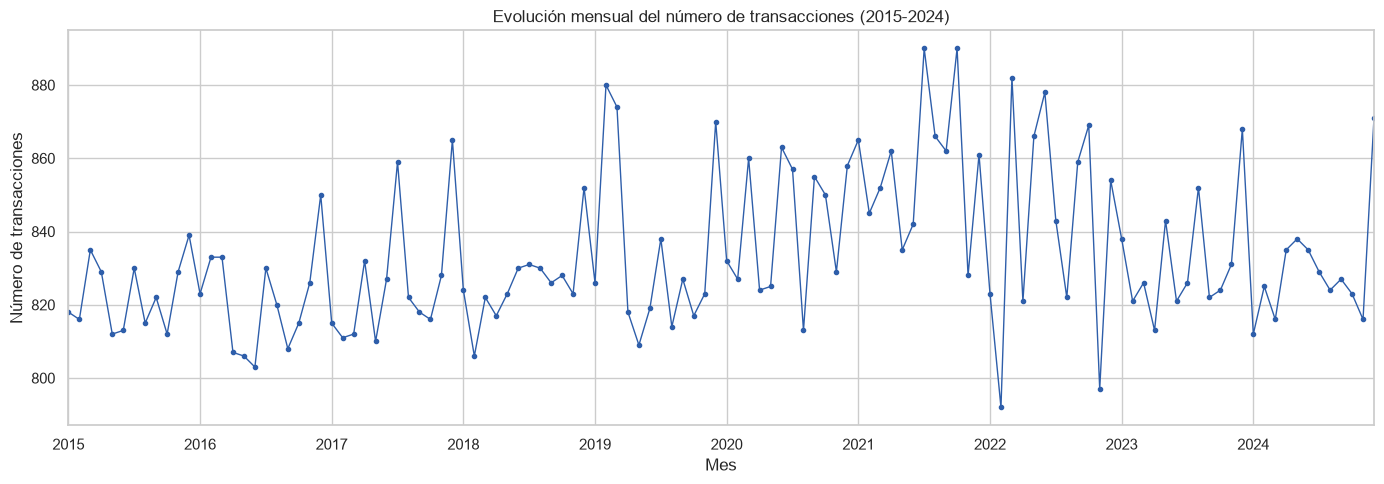

In [179]:
ejes = transacciones_mes.plot(
    figsize=(14, 5),   # tamaño del gráfico, que sea alargado porque son 9 años
    marker="o",   # que haya un punto bold en el numero exacto de transacciones
    markersize=3, # tamaño del punto
    linewidth=1,  # tamaño de la línea
    color="#2E5EAA",  # color de las líneas
    title="Evolución mensual del número de transacciones (2015-2024)" # título
)
ejes.set_xlabel("Mes")   # establecer eje x
ejes.set_ylabel("Número de transacciones") # establecer eje y
plt.tight_layout()  # ajustar márgenes/texto
plt.show()  # mostramos el gráfico

**CONCLUSIONES:** Podemos ver que hay meses con picos altos que se mantienen a lo largo de estos 9 años. Por ejemplo, Diciembre, que puede verse afectado por el periodo de Navidad.

El número de transacciones, en general , parece crecer muy poco cada año, se mantiene bastante estable. Si comparamos 2015 con 2024, no hay una crecimiento significativo y es algo de debe estudiarse ya que para que un empresa considere que tiene un rendimiento positivo debe crecer al menos un 5% anual y en 9 años no se ha dado este caso.

En 2024 hay ciertas anomalías, 2 meses con pico muy bajos ¿que pasó en esos meses? y meses con picos muy altos.

**Limitaciones/problemas:** Se han contado tanto las transacciones aceptadas como las rechazadas.

**Medidas empresariales/acciones:** Aunque este gráfico nos da información claro, sería más relevante comparar este gráfico con las campañas de marketing de la empresa, que ya aparecen en el dataframe. Si en los picos de más transacciones coinciden con campañas excepcionales (SUMMER_TRAVEL, BLACK_FRIDAY, etc.) se podrían tomar como refencia para mejorar los resultados del sigiente año y comprobar si cumplen su objetivo.



---

✨ **SOLUCIÓN/RESPUESTA IA:**

*¡Claro! Te muestro otra alternativa con un mapa de calor para visualizar la evolución mensual del número de transacciones por año. Este tipo de gráfico es excelente para identificar patrones estacionales y tendencias a lo largo del tiempo.*



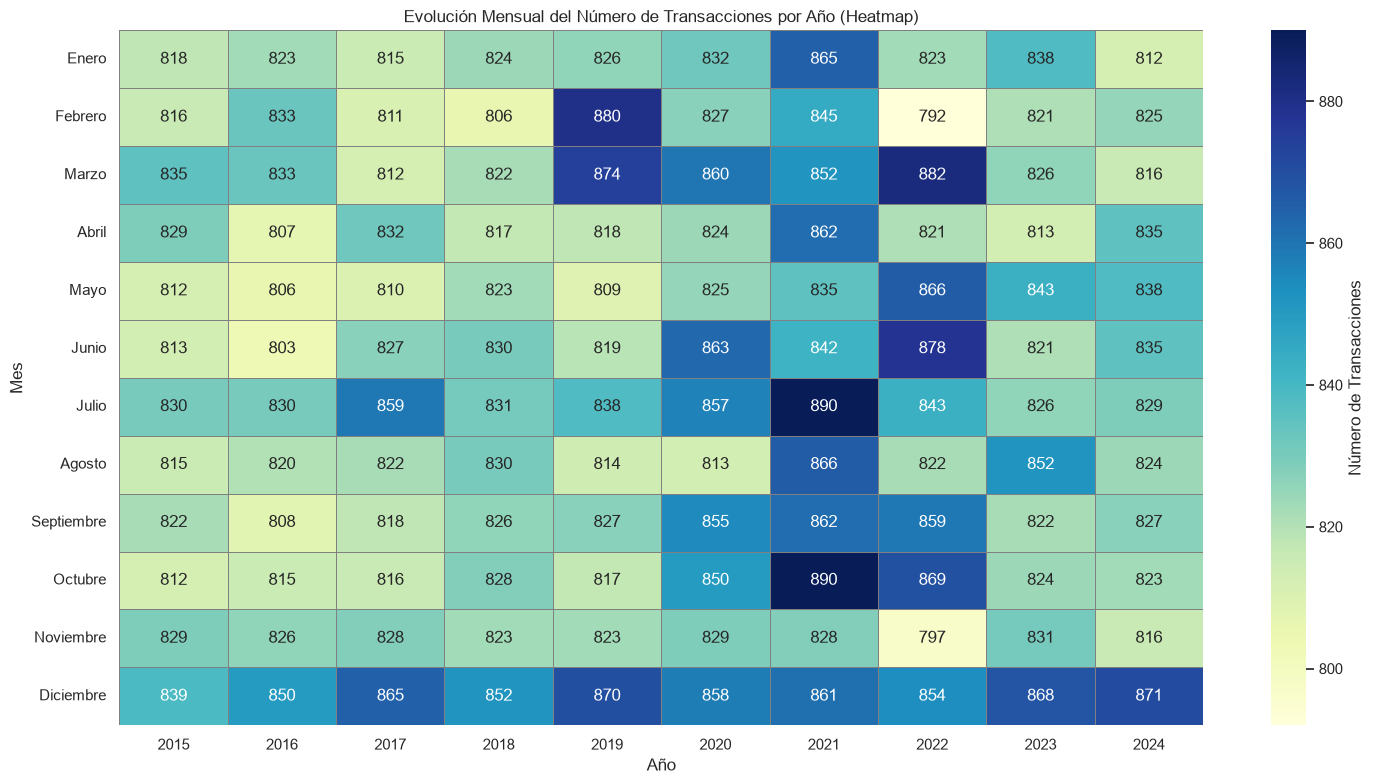

In [180]:
# Asegurarse de que transacciones_mes sea un DataFrame con columna de fecha
df_monthly_transactions = transacciones_mes.to_frame(name='transactions_number').reset_index()
df_monthly_transactions.rename(columns={'month': 'month_date'}, inplace=True)

# Extraer el año y el número de mes
df_monthly_transactions['year'] = df_monthly_transactions['month_date'].dt.year
df_monthly_transactions['month_num'] = df_monthly_transactions['month_date'].dt.month

# Mapear números de mes a nombres en español para mayor legibilidad
month_names_es = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
    7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
df_monthly_transactions['month_name'] = df_monthly_transactions['month_num'].map(month_names_es)

# Definir el orden específico para los meses
month_order = [
    'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
    'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'
]
df_monthly_transactions['month_name'] = pd.Categorical(df_monthly_transactions['month_name'], categories=month_order, ordered=True)

# Pivotar la tabla para preparar los datos para el mapa de calor
heatmap_data = df_monthly_transactions.pivot_table(index='month_name', columns='year', values='transactions_number')

plt.figure(figsize=(15, 8))
sns.heatmap(
    heatmap_data,
    annot=True,      # Mostrar el número de transacciones en el mapa de calor
    fmt=".0f",       # Formato de las anotaciones como enteros
    cmap="YlGnBu",    # Mapa de colores
    linewidths=.5,   # Líneas entre las celdas
    linecolor='gray', # Color de las líneas para mejor separación
    cbar_kws={'label': 'Número de Transacciones'} # Etiqueta de la barra de color
)
plt.title('Evolución Mensual del Número de Transacciones por Año (Heatmap)')
plt.xlabel('Año')
plt.ylabel('Mes')
plt.yticks(rotation=0) # Asegurar que los nombres de los meses estén horizontales
plt.tight_layout()
plt.show()

🚩**COMPARACIÓN DE RESULTADOS SILVIA vs IA**

En un gráfico de líneas los extremos se resaltan más aunque en nivel de transacciones se establece entre 800 y 880 que no es tan distante. Aquí la comparativa con campañas de marketing es más fácil de ver y analizar.

En el mapa de color propuesto por la IA, las diferencias en cuanto a número de transacciones no se ve a simple vista, creo que se mantienen bastante estables durante los 9 años que estamos analizando. Pero si se resalta por el color más oscuro que Diciembre siempre es un mes más potente y que entre 2020-2022 las transacciones se incrementaron y estaría bien analizar por qué y repetir patrones.



---

**2. ¿Qué usuarios generan más volumen de negocio?**

**➡ Ejemplo de pasos guiados con seaborn.**

* Identifica la columna que representa al usuario.
* Agrupa las transacciones por usuario y calcula los ingresos totales sumando la columna «importe».
* Ordena a los usuarios de mayor a menor según sus ingresos.
* Selecciona los N usuarios principales (por ejemplo, los 15 primeros).
* Visualiza el resultado mediante un gráfico de barras con Seaborn.

---

🔹 *user_id* es la columna que representa al usuario.

🔹 Esta vez vamos a tener en cuenta las transacciones aceptadas. Si no, no será real la información.

In [181]:
# Transacciones aceptadas (declined == 0),
accepted = df_transactions[df_transactions["declined"] == 0]

In [182]:
# Agrupamos por usuario y sumamos el importe
revenue_user = accepted.groupby("user_id")["amount"].sum()

# Ordenamos de mayor a menor
revenue_user = revenue_user.sort_values(ascending=False)

In [183]:
# Seleccionamos los 10 usuarios principales
top15_users = revenue_user.head(15).reset_index()
top15_users.columns = ["user_id", "total_revenue"]
top15_users

,user_id,total_revenue
0,289,47332.90
1,318,46393.44
2,455,40594.55
3,417,37393.91
4,185,34560.87
5,285,33217.28
6,454,29528.42
7,349,27835.38
8,193,27076.83
9,317,22484.76


🔹 El gráfico de barras nos permitirá ver fácilmente la diferencia entre los usuarios.

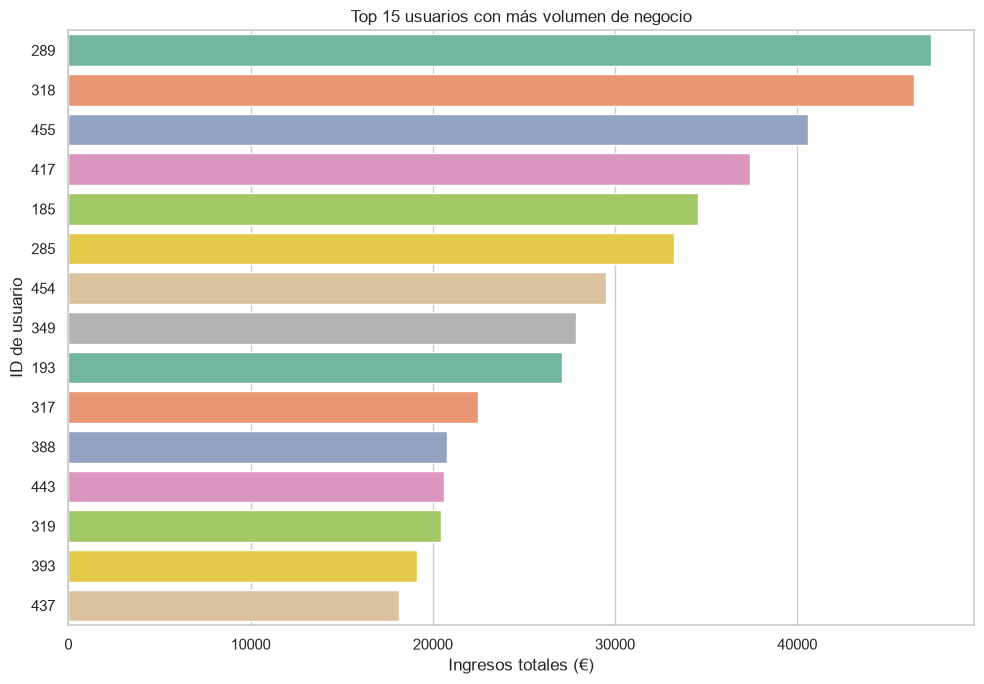

In [184]:
plt.figure(figsize=(10, 7))  # tamaño del gráfico
sns.barplot(
    data=top15_users,  # utilizamos el df de top 15 users
    x="total_revenue",  # eje x
    y="user_id",  # eje y
    hue="user_id",  # le damos un color diferente a cada usuario
    order=top15_users.sort_values("total_revenue", ascending=False)["user_id"],  #ordenamos las barras de mayor a menor para ver el decrecimiento de transacciones
    palette="Set2",  # paleta de colores
    legend=False,  # quitams la leyenda, en este caso no es necesaria, ya vemos en el eje y el usuario
    orient="h"  #gráfico horizontal para ver mejro el decrecimiento por usuario
)
plt.title("Top 15 usuarios con más volumen de negocio")
plt.xlabel("Ingresos totales (€)")
plt.ylabel("ID de usuario")
plt.tight_layout()
plt.show()

**CONCLUSIONES:** En el gráfico podemos ver que en este Top 15, el usuario nº 15 ha hecho menos de la mitad de revenue que el nº 1. Este gréfico en horizontal nos muestras de una forma muy clara el decreciemiento de inversión por parte de cada usuario.

El Top 5 es más estable.

**Limitaciones/problemas:** No sabemos el número de transacciones, puede que el primero haga pocas de muy alto importe y el último haga muchas de poco importe.

**Medidas empresariales/acciones:** Acción que permita da algún beneficio al nº 1 o Top5. Campaña de retención.
Por otro lado, cómo hacer que los último 5 inviertan más, sabemos que hacen transacciones pero necesitamos que su revenue se incremente.



---



✨ **SOLUCIÓN/RESPUESTA IA:**

*¡Claro! Te muestro otra alternativa con un gráfico de Lollipop para visualizar los Top 15 usuarios con mayor volumen de negocio. Este tipo de gráfico es más ligero visualmente y sigue destacando claramente la contribución de cada usuario.*

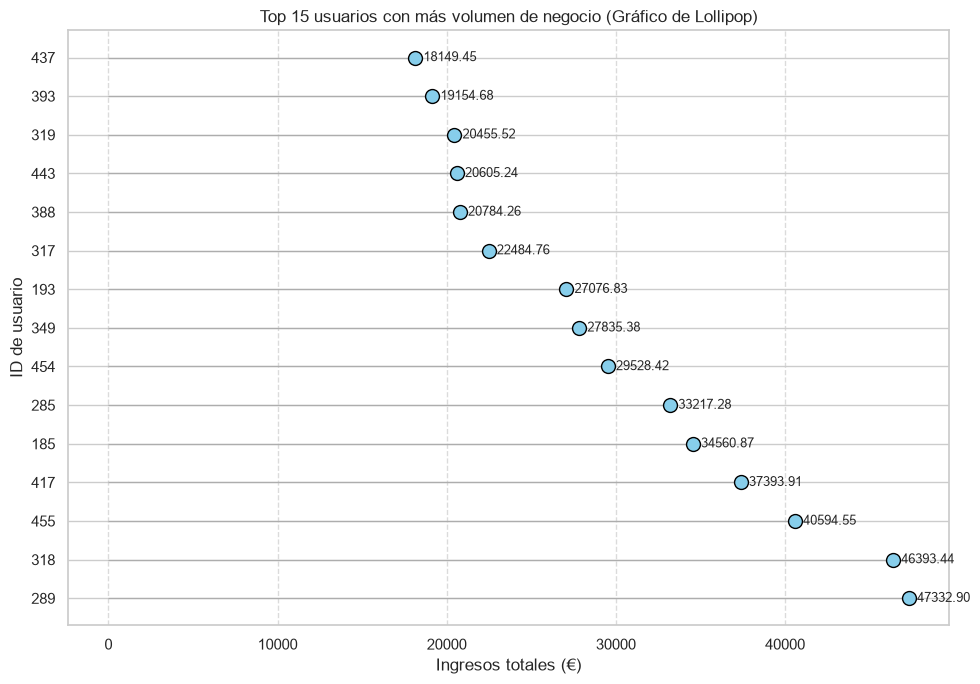

In [185]:
# Sort `top15_users` in descending order of total_revenue for consistent ranking
df_sorted = top15_users.sort_values(by='total_revenue', ascending=False)

# Convert user_id to categorical type with the desired order for plotting
df_sorted['user_id'] = pd.Categorical(df_sorted['user_id'], categories=df_sorted['user_id'].tolist(), ordered=True)

plt.figure(figsize=(10, 7))

# Create the lollipop chart
plt.hlines(
    y=df_sorted['user_id'],
    xmin=0,
    xmax=df_sorted['total_revenue'],
    color='grey',
    alpha=0.4,
    linewidth=1
)
plt.scatter(
    x=df_sorted['total_revenue'],
    y=df_sorted['user_id'],
    color='skyblue', # Using skyblue for consistency with previous monochromatic attempts
    s=100, # Size of the circles
    marker='o',
    edgecolor='black',
    zorder=3 # Ensures points are on top of lines
)

# Add value labels
for index, row in df_sorted.iterrows():
    plt.text(
        x=row['total_revenue'] + (df_sorted['total_revenue'].max() * 0.01), # Offset text slightly to the right
        y=row['user_id'],
        s=f"{row['total_revenue']:.2f}",
        ha='left',
        va='center',
        fontsize=9
    )

plt.title("Top 15 usuarios con más volumen de negocio (Gráfico de Lollipop)")
plt.xlabel("Ingresos totales (€)")
plt.ylabel("ID de usuario")
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add horizontal grid for better readability
plt.tight_layout()
plt.show()

🚩**COMPARACIÓN DE RESULTADOS SILVIA vs IA**

El gráfico de barras horizontal nos muestra una comparación directa de los ingresos generados por cada uno de los 15 usuarios principales de mayor a menor pero no y el número de usuario de forma clara.

Sin embargo, en el gráfico propuesto por la IA, los datos se superponen, no vemos en ningún momento el id de usuario, sólo un rango y no veo el decrecimiento o el orden a primera vista.

Desde mi punto de vista, el gráfico de barras es más útil para este caso. Quizá añadiría el número de transacciones.



---

**3. ¿Existen diferencias en la distribución de los importes de las transacciones según la hora del día y según si fueron aceptadas o rechazadas?**

**➡ Ejemplo de pasos guiados con Seaborn.**

* Crea una nueva columna con la hora del día a partir de la marca de tiempo.
* Utiliza un gráfico de violín de Seaborn para analizar la distribución de los importes.
* Establece: X para la hora del día, Y para el importe de la transacción y el tono de color para el estado de la transacción.
* Activa «split» para comparar las transacciones aceptadas y rechazadas, y «inner» con «quartile» para mostrar la mediana y los cuartiles.
---
🔹Utilizaremos de nuevo la columna de "timestamp" pero en este caso no utilizaremos la fecha, si no la hora. La extraemos en una nueva columna.


In [186]:
#  Creamos una nueva columna con la hora del día de las transacciones, extrayéndola de "timestamp"
df_transactions["hour"] = df_transactions["timestamp"].dt.hour

#  Creamos una nueva columna para establecer de forma clara si las transacciones fueron aceptadas o rechazadas, importante a tener en cuenta para que los datos sean reales.
df_transactions["status"] = df_transactions["declined"].map({0: "Accepted", 1: "Declined"})

df_transactions[["timestamp", "hour", "amount", "status"]].head()

,timestamp,hour,amount,status
0,2024-08-28 07:16:46,7,433.51,Accepted
1,2020-07-14 15:37:45,15,332.38,Accepted
2,2017-09-04 19:44:53,19,175.00,Accepted
3,2017-01-05 18:19:25,18,158.55,Accepted
4,2023-09-23 04:51:43,4,317.97,Accepted


In [187]:
# vamos a contar cuántas transacciones hay de cada tipo. Importante para saber si la comparación es equitativa
df_transactions.groupby("status").count()["id"]

status
Accepted    99111
Declined      888
Name: id, dtype: int64

🔹Un gráfico de violín nos permite comparar distribuciones de probabilidad entre las transacciones aceptadas y rechazadas.

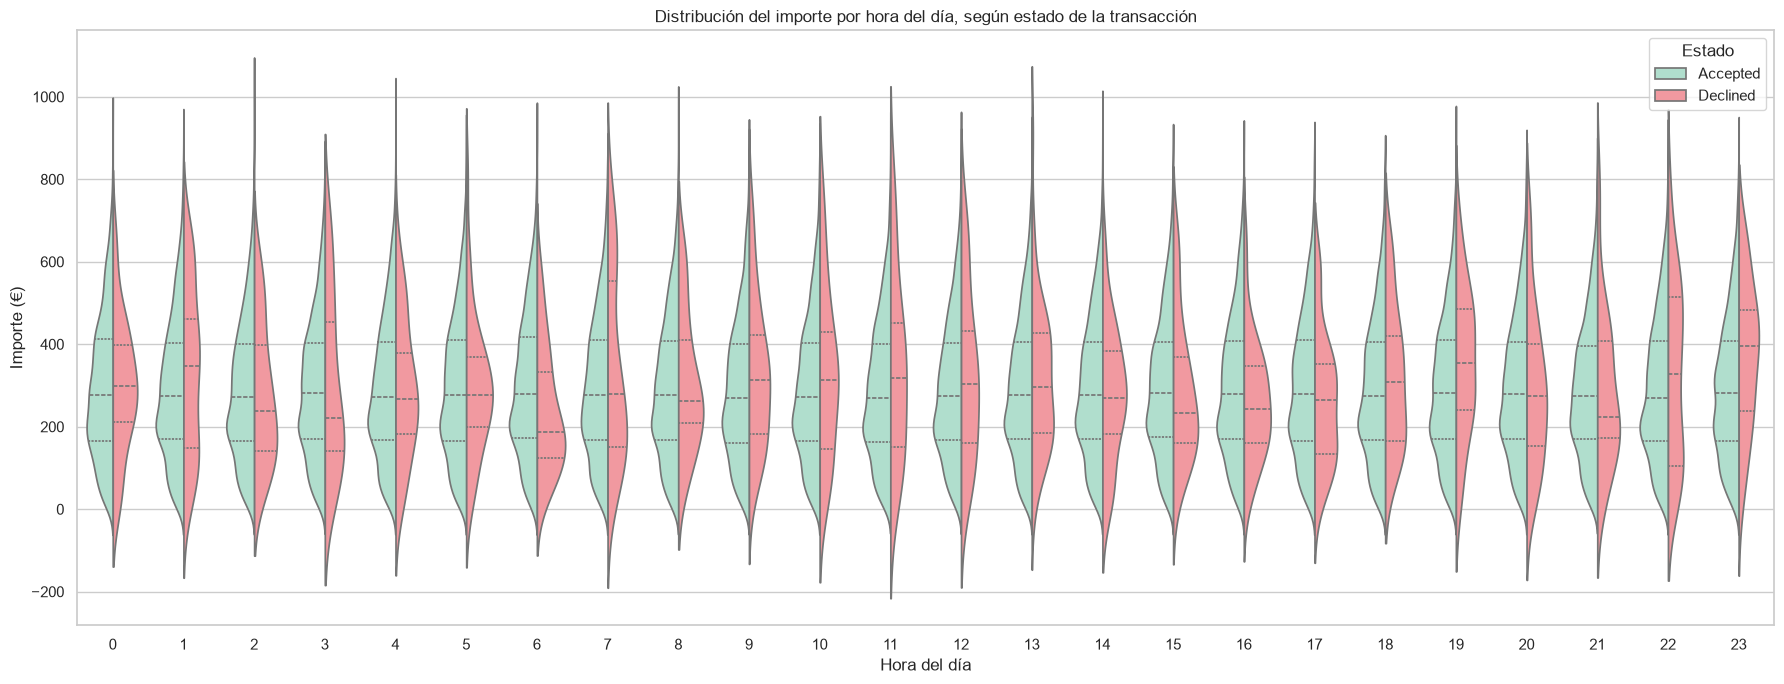

In [188]:
# gráfico de violín seaborn: X = hora del dia, Y = importe transacción, hue = estado de la transacción, split para comparar --> True
plt.figure(figsize=(18, 7))
sns.violinplot(
    data=df_transactions,
    x="hour",
    y="amount",
    hue="status",
    split=True,
    inner="quartile",   # muestra mediana y cuartiles dentro del violín --> 25%, 50% o mediana, y 75% con líneas
    palette={"Accepted": "#A8E6CF", "Declined": "#FF8B94"}

)
plt.title("Distribución del importe por hora del día, según estado de la transacción")
plt.xlabel("Hora del día")
plt.ylabel("Importe (€)")
plt.legend(title="Estado")  #mostramos la leyenda para saber cúales son las aceptadas y cuáles las rechazadas
plt.tight_layout()
plt.show()

**CONCLUSIONES:** - Los violines más anchos nos muestran si hay más trasnsacciones en determinadas horas del día. En este caso, no parece haber una diferencia significativa entre horas, parece bastnte estable.

Podemos ver, gracías a las líneas de los cuartiles si las transferencias rechazadas tienen un importe más alto. Ésto nos puede dar algún tipo de información que ayude a identificar qué pasa. Quizás al ser improtes más altos el banco las rechaza, el cliente se lo piensa más, etc.

**Limitaciones/problemas:**
No hay una comparativa muy clara o real, ya que se está comparando un número muy alto de transferencias aceptadas con un número muy bajo (alrededor del 1%) de rechazadas.

**Medidas empresariales/acciones:**
Proponer pago a plazos para facilitar el pago de transacciones de valor alto.


---



✨ **SOLUCIÓN/RESPUESTA IA:**

*¡Claro! Una buena alternativa al gráfico de violín es un gráfico de cajas (boxplot). Este tipo de gráfico muestra la mediana, los cuartiles y los valores atípicos de la distribución de los importes de las transacciones por hora y estado, ofreciendo una vista más tradicional de la dispersión de los datos*

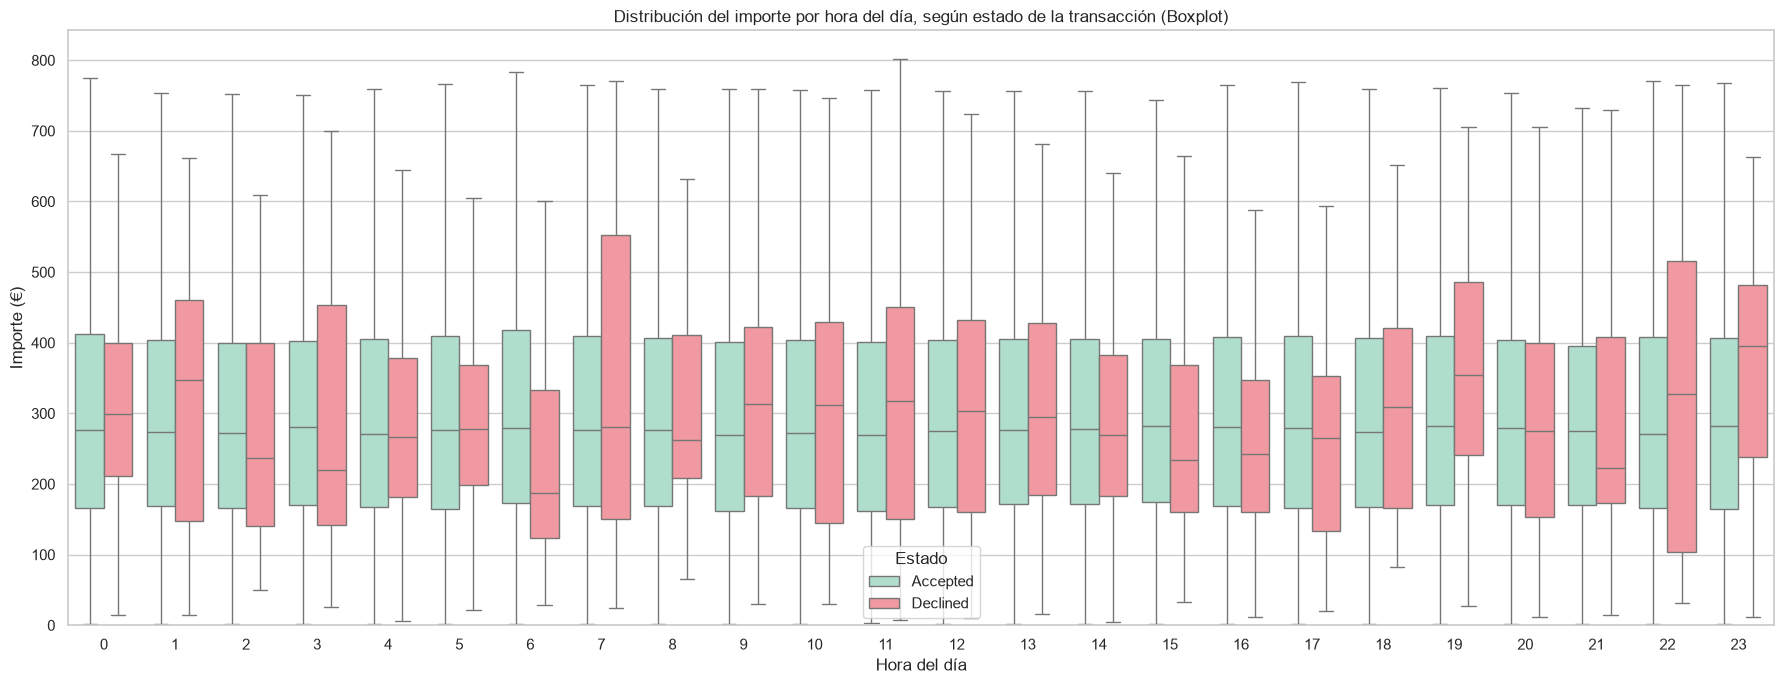

In [189]:
# Gráfico de cajas (boxplot) para comparar la distribución del importe por hora y estado
plt.figure(figsize=(18, 7))
sns.boxplot(
    data=df_transactions,
    x="hour",
    y="amount",
    hue="status",
    palette={"Accepted": "#A8E6CF", "Declined": "#FF8B94"},
    showfliers=False # Opcional: ocultar los puntos atípicos para una vista más limpia de la distribución principal
)
plt.title("Distribución del importe por hora del día, según estado de la transacción (Boxplot)")
plt.xlabel("Hora del día")
plt.ylabel("Importe (€)")
plt.legend(title="Estado")
plt.ylim(bottom=0) # Asegurar que el eje Y comience en 0
plt.tight_layout()
plt.show()

🚩**COMPARACIÓN DE RESULTADOS SILVIA vs IA**

Desde mi punto de vista, un gráfico de violín en este caso es más claro ya que nos muestra el revenue total por el ancho del violín.

En el gráfico que nos propone la IA, el ancho es estándar asi que no podemos ver la diferencia en el importe total. Sin embargo, si nos es más fácil identificar los cuartiles en este último.

---

**4. ¿En qué días de la semana se registra mayor actividad de ventas?**

🔹Para contestar a este pregunta debemos saber en qué dia de la semana se hicieron las transacciones. Solo sabemos la fehcas, asi que necesitamos extraerlo de esta columna.


In [190]:
# creamos una nueva columna con el nombre del día de la semana
df_transactions["week_day"] = df_transactions["timestamp"].dt.day_name()

In [191]:
#comprobamos
df_transactions[["id", "week_day"]]

,id,week_day
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,Wednesday
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,Tuesday
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,Monday
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,Thursday
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,Saturday
...,...,...
99994,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,Saturday
99995,FFFB270D-F53A-4D5D-9666-E5307C53CC84,Monday
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,Wednesday
99997,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,Saturday


In [192]:
ventas_dia = (df_transactions[df_transactions["status"] == "Accepted"].groupby("week_day").size().reset_index(name="transactions_number"))


In [193]:
ventas_dia

,week_day,transactions_number
0,Friday,14138
1,Monday,13996
2,Saturday,14221
3,Sunday,14171
4,Thursday,14388
5,Tuesday,14045
6,Wednesday,14152


In [194]:
# creo una lista nueva con el orden de los días de la semana para poder, después, ordenar la tabla. Si no, sería por orden alfabético

orden = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

ventas_dia["week_day"] = pd.Categorical(  # convertimos la columna día a categórico para poder despues establecer el orden según hemos creado la lista
    ventas_dia["week_day"],  # qué queremos ordenar
    categories=orden,  # qué categoría tomar como refencia para el orden
    ordered=True)

# ordenamos
ventas_dia = ventas_dia.sort_values("week_day")

In [195]:
# comprobamos que ahora si está ordenado tal y cómo le hemos indicado
ventas_dia

,week_day,transactions_number
1,Monday,13996
5,Tuesday,14045
6,Wednesday,14152
4,Thursday,14388
0,Friday,14138
2,Saturday,14221
3,Sunday,14171


C:\Users\Dell\AppData\Local\Temp\ipykernel_20804\661622496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


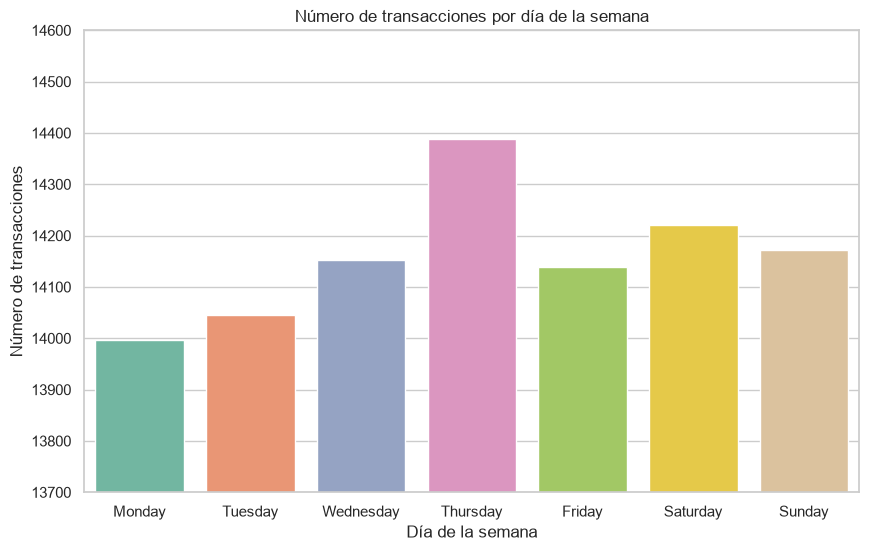

In [196]:
plt.figure(figsize=(10,6))    # establecemos tamaño del gráfico el pulgadas

sns.barplot(
    data=ventas_dia,   # df para la información
    x="week_day",    # eje x
    y="transactions_number",    # eje y
    width=0.8,   # tamaño barras
    palette="Set2"   # paleta de colores
)

plt.ylim(13700, 14600)
plt.title("Número de transacciones por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Número de transacciones")

plt.show()


**CONCLUSIONES:** - He ajustado el gráfico apra que nos muestre el importe de las ventas desde un mínimo de 13,7k para que los datos sean más claros. Podemos ver que es bastante estable y regular el importe por día, aunque destaca un poco más (aunque realmente no mucho) los jueves.

**Limitaciones/problemas:**
De nuevo, no sabemos si hay mas ventas con poco importe, o menos ventas con un revenue muy alto.

Además, al agrupar 9 años, no sabemos si todos los jueves se vende mas, si es por temporada, por festivos, etc.

**Medidas empresariales/acciones:**
En el caso real que lo jueves sean los mejores días de ventas a lo largo de 9 años, implementar campañas especiales, un push en la app, un slot o banner que ayude a generar una venta más impulsiva esos días, etc.


---

✨ **SOLUCIÓN/RESPUESTA IA:**

*¡Claro! Una buena alternativa para visualizar la actividad de ventas por día de la semana, especialmente para mostrar la proporción, es un gráfico de pastel.*

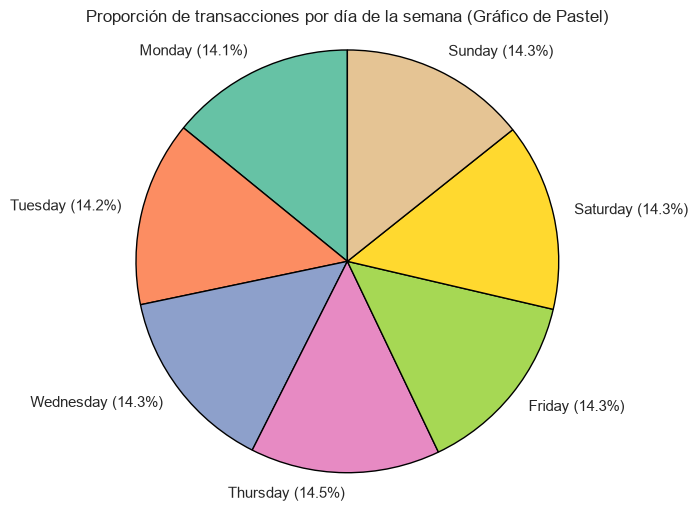

In [197]:
plt.figure(figsize=(6, 6))

# Calculate percentages for the pie chart
percentages = ventas_dia['transactions_number'] / ventas_dia['transactions_number'].sum() * 100
# Convert 'week_day' to string before concatenation to avoid TypeError
labels = ventas_dia['week_day'].astype(str) + ' (' + percentages.round(1).astype(str) + '%)'

plt.pie(
    ventas_dia['transactions_number'],
    labels=labels,
    colors=sns.color_palette("Set2"),
    autopct='', # No default autopct to use custom labels
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Proporción de transacciones por día de la semana (Gráfico de Pastel)")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

🚩**COMPARACIÓN DE RESULTADOS SILVIA vs IA**

En comparación con el gráfico de pastel que nos propone la IA, en un gráfico de barras ajustando el revenue se puede apreciar mejor que los jueves tienen ligeramente más transacciones, seguidos por los sábados y domingos. Los lunes y martes tienen la menor cantidad de transacciones.

Sin embargo, en el pastel, aunque nos muestra el porcentaje que es muy útil, la diferencia es mu sútil y no puedo identificar una posible acción en días específicos.





---

## **Ejercicio 2: Preguntas analíticas complejas (con orientación)**


🌍 Contexto: Este ejercicio requiere combinar información de varias tablas del modelo para responder correctamente a las preguntas.

Tendrás que:

» Combinar tablas.

» Utilizar groupby, pivot_table, crosstab...

» Aplicar agregaciones, transformaciones intermedias y funciones.

Preguntas analíticas (con orientación general)

» ¿Dependemos en exceso de un número reducido de países en lo que respecta a nuestras empresas vendedoras?

🚀 **Pasos orientativos:**

1. Combina la información de las transacciones con la de las empresas.

2. Agrupa la facturación por país.

3. Calcular los ingresos totales generados por cada país.

4. Ordenar los países de mayor a menor volumen de negocio.

5. Calcular el porcentaje acumulado del total.

6. Visualizar.

⚡ **¿Existe estacionalidad en las ventas?**

1. Trabaja con las fechas de las transacciones.

2. Extrae la información temporal relevante (año y mes).

3. Calcula el volumen total de ventas (suma de los importes) por año y por mes.

4. Compara los patrones temporales con comparativas interanuales. Crea una tabla dinámica.

5. Visualiza la tendencia.

**» Análisis de concentración y variabilidad (elige UNA opción)**

▶ ***Opción A – Producto (solo si dispones de la tabla de productos)***

¿Qué productos generan más ingresos y con qué variabilidad?

Pasos a seguir:

1. Combina las transacciones, la tabla puente y los productos.

2. Calcula los ingresos por producto utilizando las funciones «agrupar por», «suma» y «ordenar».

3. Selecciona los N productos principales: 15, por ejemplo.

4. Elige una visualización adecuada para analizar la dispersión.

▶ ***Opción B – Actividad de los usuarios (alternativa si no dispones de la tabla de productos)***

¿Hay algún usuario que haya dejado de comprar recientemente?

Pasos guiados:

1. Identifica la última compra de cada usuario.

2. Calcula el tiempo transcurrido desde la última compra.

3. Visualiza la distribución del tiempo transcurrido desde la última compra.

**» ¿Cómo varía la actividad de ventas por franjas horarias a lo largo de los años? (patrones temporales)**

Pasos a seguir:

1. Crea franjas horarias a partir de la hora: crea una función y aplícala con «apply».

2. Crea una tabla agregada utilizando «crosstab».

3. Visualízala con un mapa de calor.

👉 **Para cada pregunta:**

» Describe brevemente los pasos que has seguido.

» Muestra la visualización final.

» Interpreta qué implica esto para el negocio.




---

**>> Cargamos companies**

* Transactions: Ya lo tenemos cargado
* Companies: Nuestro archivo está separado por ",", por eso debemos indicarlo, para que pueda leer cada columna.

In [198]:
consulta2 = "SELECT * FROM companies;"

conexion = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234",
    database="product_transactions"
)


df_companies = pd.read_sql(consulta2, conexion)


conexion.close()


df_companies.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_20804\3212969825.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_companies = pd.read_sql(consulta2, conexion)


,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Germany,https://www.ac-fermentum-incorporated.com,Beauty,mid-market
1,b-2226,Magna A Neque Industries,+33 823 560 3779,risus.donec.nibh@icloud.org,Australia,https://www.magna-a-neque-industries.com,Travel,budget
2,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,b-2234,Convallis In Incorporated,+6 693 982 1255,mauris.ut@aol.couk,Germany,https://www.convallis-in-incorporated.com,Sports,mid-market
4,b-2238,Ante Iaculis Nec Foundation,+69 914 549 1009,sed.dictum.proin@outlook.ca,New Zealand,https://www.ante-iaculis-nec-foundation.com,Toys,mid-market


In [199]:
df_companies.head()

,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Germany,https://www.ac-fermentum-incorporated.com,Beauty,mid-market
1,b-2226,Magna A Neque Industries,+33 823 560 3779,risus.donec.nibh@icloud.org,Australia,https://www.magna-a-neque-industries.com,Travel,budget
2,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,b-2234,Convallis In Incorporated,+6 693 982 1255,mauris.ut@aol.couk,Germany,https://www.convallis-in-incorporated.com,Sports,mid-market
4,b-2238,Ante Iaculis Nec Foundation,+69 914 549 1009,sed.dictum.proin@outlook.ca,New Zealand,https://www.ante-iaculis-nec-foundation.com,Toys,mid-market


**>> Explorar el dataset**

Para poder trabajar con él y saber como responder al enunciado del ejercicio.

In [200]:
df_companies.describe()

,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
count,100,100,100,100,100,100,100,100
unique,100,100,100,100,15,100,10,3
top,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Sweden,https://www.ac-fermentum-incorporated.com,Electronics,mid-market
freq,1,1,1,1,11,1,15,51


🚩 IMPORTANTE: company_id = business_id


---

**>> Combina la información de las transacciones con la de las empresas.**

💠 Utilizando *merge* combinamos ambas tablas teniendo en cuenta el id de la compñía.

In [201]:
df_sales = pd.merge(
    df_transactions,
    df_companies,
    left_on="business_id",
    right_on="company_id",
    how="left"
)

In [202]:
df_sales.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,status,week_day,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,Accepted,Wednesday,b-2458,Eget Tincidunt Dui Institute,+18 210 327 5206,eget.laoreet@hotmail.org,Netherlands,https://www.eget-tincidunt-dui-institute.com,Toys,mid-market
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,Accepted,Tuesday,b-2390,Neque Tellus Imperdiet Corp.,+12 445 145 3593,vestibulum.ante.ipsum@aol.edu,Ireland,https://www.neque-tellus-imperdiet-corp.com,Food,budget
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,...,Accepted,Monday,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,...,Accepted,Thursday,b-2266,Mus Aenean Eget Foundation,+1 504 922 3000,mi.duis@hotmail.net,Sweden,https://www.mus-aenean-eget-foundation.com,Sports,mid-market
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,...,Accepted,Saturday,b-2598,Aliquam Iaculis Lacus Corp.,+23 674 242 3712,dictum@aol.org,Belgium,https://www.aliquam-iaculis-lacus-corp.com,Fashion,budget


**>> Agrupa la facturación por país / Calcular los ingresos totales generados por cada país.**

In [203]:
revenue_country = (
    df_sales
    .groupby("country")["amount"]
    .sum()
    .reset_index())

**>> Ordenar los países de mayor a menor volumen de negocio.**


In [204]:
revenue_country = revenue_country.sort_values(by="amount", ascending=False)

In [205]:
revenue_country

,country,amount
12,Sweden,4928117.68
8,Netherlands,4506571.38
13,United Kingdom,4099117.08
7,Italy,4087557.38
5,Germany,4020364.07
4,France,1416084.26
14,United States,1101737.27
1,Belgium,952208.75
10,Norway,809288.82
6,Ireland,715220.46


**>> Calcular el porcentaje acumulado del total.**

In [206]:
revenue_country["%"] = (revenue_country["amount"] / revenue_country["amount"].sum()) * 100

In [207]:
revenue_country["cumulative_percentage"] = (revenue_country["%"].cumsum())  # calculamos la suma acumulada de los porcentajes

In [208]:
revenue_country

,country,amount,%,cumulative_percentage
12,Sweden,4928117.68,16.822212,16.822212
8,Netherlands,4506571.38,15.383256,32.205468
13,United Kingdom,4099117.08,13.992404,46.197872
7,Italy,4087557.38,13.952945,60.150818
5,Germany,4020364.07,13.723580,73.874397
4,France,1416084.26,4.833827,78.708224
14,United States,1101737.27,3.760798,82.469023
1,Belgium,952208.75,3.250380,85.719403
10,Norway,809288.82,2.762521,88.481924
6,Ireland,715220.46,2.441417,90.923341


**>> Visualizar.**

💠 Para poder hacer esta visualización que muestre a la vez el total de las ventas y el % que se acumula con cada uno de los países utilizaremos un gráfico de barras y un gráfico de líneas combinado.

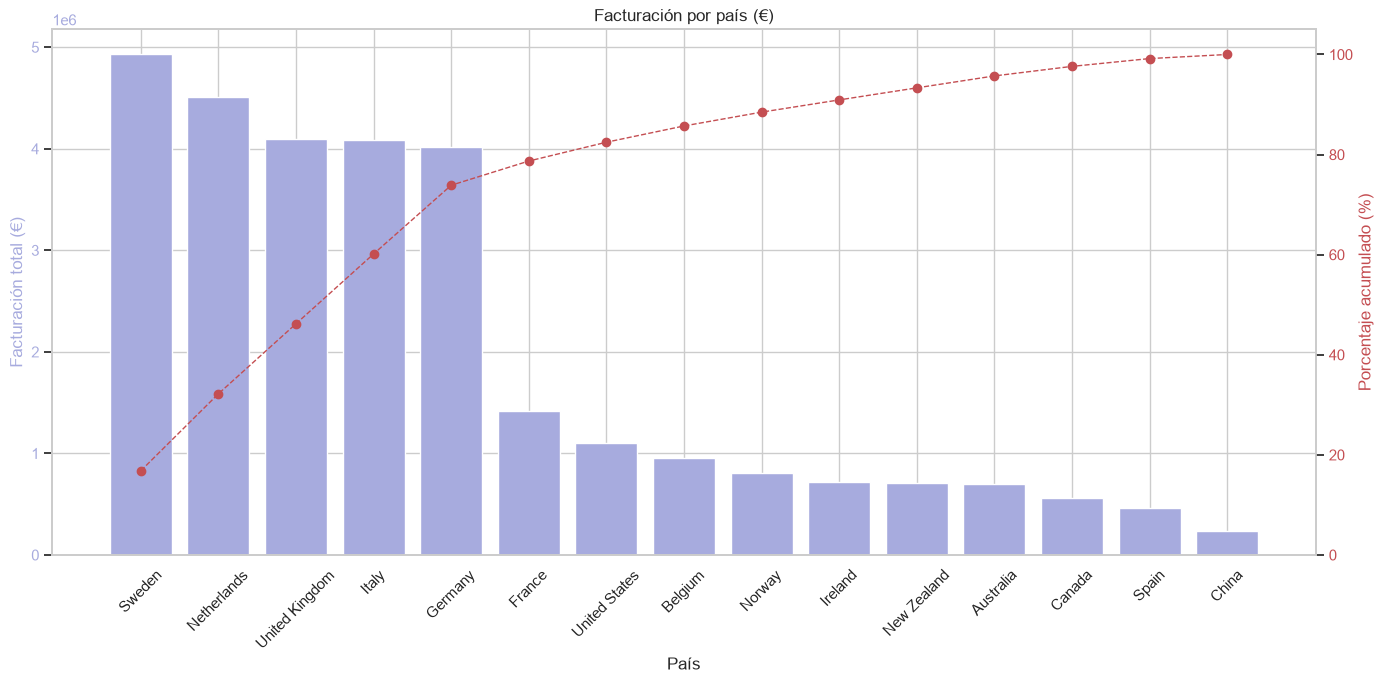

In [209]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14,7))  # tamaño

# 1º. Grafico de Barras --> facturación por país
ax1.bar(
    revenue_country["country"],     # eje x
    revenue_country["amount"],      # eje y
    color="#A7ABDE",                # color RGB
)

ax1.set_xlabel("País")   # nombre etiqueta eje x
ax1.set_ylabel("Facturación total (€)", color="#A7ABDE")  # nombre etiqueta eje y
ax1.tick_params(axis="y", labelcolor="#A7ABDE")
plt.xticks(rotation=45)    # para que los países quepan en el eje los giramos

#  2º gráfico de lineas con porcentaje acumulado
ax2 = ax1.twinx()  # establecesmo que el grafico 1 comparta el mismo eje x que este grafico
ax2.grid(False)   # quitamos la cuadricula base para que no se superpongan


ax2.plot(
    revenue_country["country"],
    revenue_country["cumulative_percentage"],
    color="r",
    marker="o",
    linestyle="--",   # estilo de la linea
    linewidth=1,      # que no sea muy gruesa y no tome todo el protagonismo
)


ax2.set_ylabel("Porcentaje acumulado (%)", color="r")
ax2.tick_params(axis="y", labelcolor="r")
ax2.set_ylim(0,105)   # del 0 al 105, si lo poenos a 100 la linea del % de corta

# Título
plt.title("Facturación por país (€)")

plt.tight_layout()   # ajustar márgenes
plt.show()

##⚡ **¿Existe estacionalidad en las ventas?**

**>> Trabaja con las fechas de las transacciones.**

**>> Extrae la información temporal relevante (año y mes).**

💠 Extraemos desde la columna "timestamp" el año y mes para poder comparar mas tarde con estas 2 columnas.

In [210]:
df_transactions["year"] = df_transactions["timestamp"].dt.year
df_transactions["month"] = df_transactions["timestamp"].dt.month_name()

In [211]:
df_transactions.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,device_type,is_international,decline_reason,distance_km,date,month,hour,status,week_day,year
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,mobile,0,,59.95,2024-08-28,August,7,Accepted,Wednesday,2024
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,pos,1,,1157.10,2020-07-14,July,15,Accepted,Tuesday,2020
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,...,pos,0,,540.32,2017-09-04,September,19,Accepted,Monday,2017
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,...,desktop,0,,28.52,2017-01-05,January,18,Accepted,Thursday,2017
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,...,pos,0,,539.82,2023-09-23,September,4,Accepted,Saturday,2023


**>> Calcula el volumen total de ventas (suma de los importes) por año y por mes.**

💠 Primero ordenamos los meses de Enero a Diciembre, si no, aparecerán por orden alfabético.


In [212]:
order_months = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

df_transactions["month"] = pd.Categorical(
    df_transactions["month"],
    categories=order_months,
    ordered=True
)

**>> Compara los patrones temporales con comparativas interanuales. Crea una tabla dinámica.**

💠 Creamos una tabla dinámica que sume todas las ventas por año y también por mes.

In [213]:
df_seasonality = pd.pivot_table(
    df_transactions,
    values="amount",
    index="month",
    columns="year",
    aggfunc="sum"
)

In [214]:
df_seasonality

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
month,,,,,,,,,,
January,224946.23,227231.14,224391.23,229524.09,224592.71,234191.13,246993.53,226680.93,231075.91,227399.39
February,248775.83,251111.47,253354.90,246504.98,262006.66,249356.44,258837.10,237503.38,252680.15,253739.68
March,254702.98,248245.83,240338.05,239145.90,280530.50,260821.35,253110.77,274387.47,243909.57,248588.94
April,247957.49,242394.40,253125.97,237432.05,244347.66,246533.40,261597.02,241191.04,245386.83,245734.27
May,252596.43,243533.92,240919.28,246838.08,244739.50,254171.48,243414.73,279590.23,264790.26,257877.46
June,233084.63,233245.79,241065.64,243421.44,245470.13,238902.90,236504.81,261954.89,234527.22,247029.50
July,243774.43,238618.15,244380.32,233449.29,233962.91,242644.23,253553.62,235935.19,240041.34,231264.22
August,238550.36,238392.03,233894.55,231129.56,240040.21,234433.92,239433.71,246434.63,239288.98,239210.63
September,227985.24,242774.67,235830.55,238772.22,235021.45,258779.26,247648.05,255496.48,237105.34,236592.54


**>> Visualiza la tendencia.**

💠 Utilizaremos un mapa de calor que nos permite visua

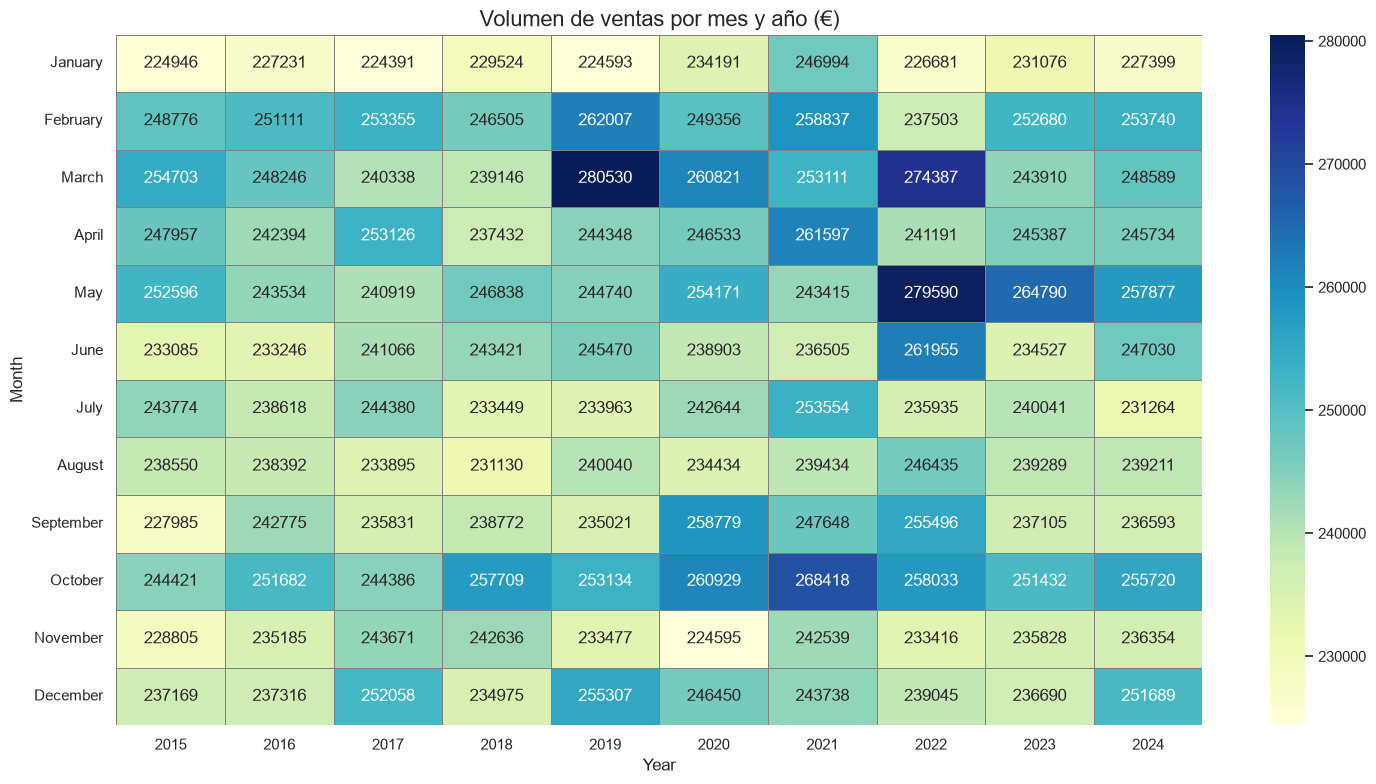

In [215]:
plt.figure(figsize=(15, 8))
sns.heatmap(
    data=df_seasonality,
    annot=True,      # Mostrar el número de transacciones en el mapa de calor
    fmt=".0f",       # numeros enteros
    cmap="YlGnBu",    # colores
    linewidths=.5,   # lineas
    linecolor="gray", # color de las líneas
)
plt.title("Volumen de ventas por mes y año (€)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Month")
plt.yticks(rotation=0) # Asegurar que los nombres de los meses estén horizontales
plt.tight_layout()
plt.show()

**CONCLUSIONES / INTERPRETACIÓN**

El mapa de calor nos muestra la evolución de las ventas y deja en evidencia los meses con un volumen mayor o menor. SIn embargo, el rango en el que mueven las ventas no es muy significativo (500€) por lo que extraer conclusiones de tendencia en este caso no es muy fiable.

Además, no hay picos de ventas muy marcados y no hay una coherencia en los mismos meses de cada año. Por ejemplo, si nos fijamos en Dicimbre, no hay apenas tendencia o color que se repita. Tampoco tienen nada que ver con las campañas de marketing (christmas, black friday, etc)

Como ya he comentado anteriormente, no hay un creciemiento o decrecimiento anual en las ventas, no solo estacional, no es habitual en una empresa real. No se permitiría ser tan estable a lo largo de los años.



---

**🎯 Análisis de concentración y variabilidad**

➡ Opción A – Producto
---


---



¿Qué productos generan más ingresos y con qué variabilidad?


💠 Primero de todo nos contactamos a nuestra tabla "products" que ya tenemos en MySQL.


In [216]:
conexion = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234",
    database="product_transactions"
)
products_table = "SELECT * FROM products;"


df_products = pd.read_sql(products_table, conexion)

conexion.close()

df_products.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_20804\2139685347.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql(products_table, conexion)


,id,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4,Sports,Runway Pro,63.84,2014-11-01
1,2,Tarly Stark,9.24,#919191,2.0,WH-3,Gaming,Questbyte,4.74,2013-02-07
2,3,duel tourney Lannister,171.13,#d8d8d8,2.0,WH-2,Food,Daily Pantry,107.07,2013-08-18
3,4,warden south duel,71.89,#111111,3.0,WH-1,Books,NorthPress,39.17,2013-12-31
4,5,skywalker ewok,171.22,#dbdbdb,3.0,WH-0,Home,NordHaus,83.69,2014-07-17


**>> Combina las transacciones, la tabla puente y los productos.**

💠 Primero tenemos que crear la tabla puente para después combinarlas.

Nos quedamos únicamente con el id de la transacción, los productos y el importe.

In [217]:
transactions_products = df_transactions[["id", "product_ids", "amount"] ].copy()


In [218]:
transactions_products

,id,product_ids,amount
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,"16, 26, 97, 87",433.51
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,"30, 11, 16, 81",332.38
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,72,175.00
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,18,158.55
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,"35, 33, 19",317.97
...,...,...,...
99994,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,"20, 42, 54, 46",278.42
99995,FFFB270D-F53A-4D5D-9666-E5307C53CC84,"30, 87, 5, 66",403.66
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,"16, 49",295.43
99997,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,18,183.02


💠 Como hay muchos productos en un mismo registro, tenemos que separarlos y hacer una fila por cada uno de los productos de cada transacción. EL id de la transaccion se repetirá.

In [219]:
transactions_products["product_ids"] = (  transactions_products["product_ids"].str.split(", ")) # utilizamos split para separar la lista de prods. separados por ,
transactions_products = transactions_products.explode("product_ids")

In [220]:
transactions_products.head()

,id,product_ids,amount
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,433.51
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26,433.51
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97,433.51
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87,433.51
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,30,332.38


In [221]:
# tenemos que convertir a numero cada prodcuto par que podamos combinar con la tabla de producto.

transactions_products["product_ids"] = (transactions_products["product_ids"].astype(int))

In [222]:
transactions_products

,id,product_ids,amount
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,433.51
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26,433.51
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97,433.51
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87,433.51
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,30,332.38
...,...,...,...
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,16,295.43
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,49,295.43
99997,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,18,183.02
99998,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,48,88.87


💠 Finalmente, combinamos con la tabla de productos.

In [223]:
product_sales = pd.merge(transactions_products, df_products,
    left_on="product_ids",
    right_on="id",
    how="left"
)

In [224]:
product_sales

#podemos comprobar que el id de la transacción se repite tantas veces como productos habia el lista inicial.

,id_x,product_ids,amount,id_y,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,433.51,16,the duel warden,180.91,#666666,3.0,WH-11,Home,NordHaus,101.11,2014-05-31
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,26,433.51,26,Stark Karstark,53.01,#898989,2.0,WH-21,Food,GreenFork,30.49,2013-02-15
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,97,433.51,97,jinn Winterfell,65.25,#bababa,1.0,WH-92,Beauty,CareLab,26.25,2013-02-22
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,87,433.51,87,sith Jade,96.26,#e2e2e2,2.0,WH-82,Food,Market&Co,66.36,2013-11-10
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,30,332.38,30,Karstark warden,79.53,#606060,1.0,WH-25,Electronics,Nexa,50.18,2013-02-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
253383,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,16,295.43,16,the duel warden,180.91,#666666,3.0,WH-11,Home,NordHaus,101.11,2014-05-31
253384,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,49,295.43,49,the giantsblood maester,53.31,#e2e2e2,1.0,WH-44,Books,NorthPress,33.64,2013-11-19
253385,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,18,183.02,18,Karstark warden,148.91,#c4c4c4,1.0,WH-13,Beauty,CareLab,47.62,2013-07-11
253386,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,48,88.87,48,rock Renly in,21.53,#9e9e9e,2.0,WH-43,Beauty,Bloom,7.38,2014-07-24


**>> Calcula los ingresos por producto utilizando las funciones «agrupar por», «suma» y «ordenar».**

💠 Agrupamos por id del prodcuto, ya que es único y no puede estar repetido, sumamos el total de cada id vendido y lo ordenamos de mayor importe de ventas a menor.


In [225]:
revenue_products = (product_sales.groupby("product_ids")["amount"]
                    .sum()
                    .reset_index()
                    .sort_values(by="amount", ascending=False))

In [226]:
revenue_products

,product_ids,amount
38,39,1154841.34
66,67,1154360.96
63,64,1152983.78
11,12,1137696.37
14,15,1131994.63
...,...,...
94,95,625046.45
65,66,618614.78
74,75,614823.18
69,70,603844.06


**>> Selecciona los N productos principales: 15, por ejemplo.**

💠 Establecemos un TOP15 de los productos.

In [227]:
top15_products = revenue_products.head(15)

In [228]:
top15_products

,product_ids,amount
38,39,1154841.34
66,67,1154360.96
63,64,1152983.78
11,12,1137696.37
14,15,1131994.63
92,93,1130606.39
15,16,1130601.86
61,62,1129275.97
85,86,1116933.98
22,23,1109587.67


💠 Ahora que ya sabemos cuales son los 15 productos más vendidos de la empresa, necesitamos saber su variabilidad, es decir, la constancia de venta de esos prodcutos, si se venden todo al año o si tienen ciertos picos altos o bajos a los largo del año o de los años.

➡ Filtraremos la tabla de productos vendidos con los obtenidos del TOP15.

In [229]:
df_top15_p = product_sales[
    product_sales["product_ids"].isin(top15_products["product_ids"])
]

In [230]:
df_top15_p

,id_x,product_ids,amount,id_y,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,433.51,16,the duel warden,180.91,#666666,3.0,WH-11,Home,NordHaus,101.11,2014-05-31
6,00045D6B-ED2E-4F2F-8186-CEE074D875D0,16,332.38,16,the duel warden,180.91,#666666,3.0,WH-11,Home,NordHaus,101.11,2014-05-31
13,0009A151-9BCF-4E31-9053-A468FF77FAAB,93,457.51,93,Littlefinger Tarly Stark,192.60,#efefef,1.0,WH-88,Food,FreshBox,111.91,2013-02-23
29,000AE0D4-F06E-4146-804A-5A2FC73110D7,62,187.69,62,the duel,188.94,#666666,2.0,WH-57,Fashion,ModaNova,80.91,2013-02-08
45,00110D8C-179A-4DE6-B132-C8CC08921CFC,64,217.02,64,Direwolf,195.62,#b7b7b7,3.0,WH-59,Fashion,Arden,93.66,2014-11-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
253336,FFECBA07-4369-4603-88E6-39E612783CCB,93,213.56,93,Littlefinger Tarly Stark,192.60,#efefef,1.0,WH-88,Food,FreshBox,111.91,2013-02-23
253350,FFEF52E6-D6D3-43A2-845F-28985E864FF8,78,468.92,78,Karstark warden,178.85,#919191,1.0,WH-73,Electronics,Voltix,116.03,2013-04-02
253352,FFF205DF-6DFD-4B48-B337-EE476513A96C,12,253.36,12,duel Direwolf,181.60,#a8a8a8,2.0,WH-7,Gaming,Questbyte,99.46,2013-10-11
253369,FFF867C9-17B5-4B1F-AFD9-F8023AAA449E,12,500.57,12,duel Direwolf,181.60,#a8a8a8,2.0,WH-7,Gaming,Questbyte,99.46,2013-10-11


**>> Elige una visualización adecuada para analizar la dispersión.**

💠 Utilizaremos un gráfico de dispersión que nos permitirá ver el volumen de ingresos y la variabilidad tal y como nos pide el enunciado.

Para que no me lea el id del prodcuto como otra variable de 0 a 100, los convertité a str.

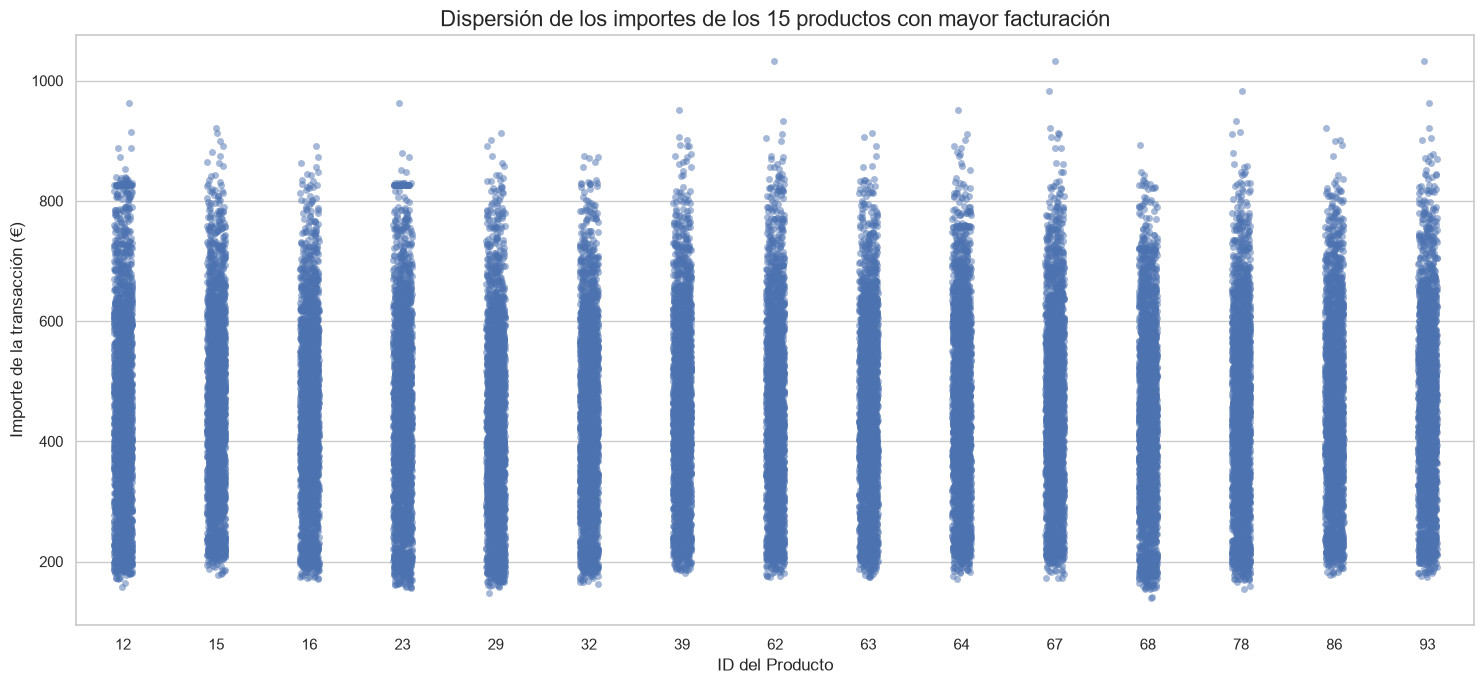

In [231]:
plt.figure(figsize=(15,7))

sns.stripplot(
    data=df_top15_p,
    x="product_ids",  # el eje x con el id de los 15 top productos
    y="amount",  # el eje y con el importe de cada transacción
    jitter=True,  # para ver mejor los puntos agrupados sin amontonar
    alpha=0.5, # transparencia de los puntos
    size=5,  # tamaño de los puntos
)

# no es necesario diferencia los productos por color, se repiten y puede llevar a confusión

plt.title("Dispersión de los importes de los 15 productos con mayor facturación", fontsize=16)
plt.xlabel("ID del Producto")
plt.ylabel("Importe de la transacción (€)")

plt.tight_layout()
plt.show()

**CONCLUSIONES / INTERPRETACIÓN**

Este gráfico de dispersión nos ayuda a ver como ha variado el importe de cada transaccion por cada producto. Podemos ver que el importe en general es bastante estable por el grosor de los punyos que se acumulan. Sin embargo, podemos ver algunos outliers que habría que revisar en algunos id.


---

##⚡ **¿Cómo varía la actividad de ventas por franjas horarias a lo largo de los años?**

Patrones temporales

---

**>> Crea franjas horarias a partir de la hora: crea una función y aplícala con «apply».**

💠 Extraemos la hora de cada transacción. El año ya lo habiamos hecho en ejercicios anteriores.




In [232]:
df_transactions["hour"] = df_transactions["timestamp"].dt.hour
df_transactions.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,device_type,is_international,decline_reason,distance_km,date,month,hour,status,week_day,year
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,mobile,0,,59.95,2024-08-28,August,7,Accepted,Wednesday,2024
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,pos,1,,1157.10,2020-07-14,July,15,Accepted,Tuesday,2020
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,...,pos,0,,540.32,2017-09-04,September,19,Accepted,Monday,2017
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,...,desktop,0,,28.52,2017-01-05,January,18,Accepted,Thursday,2017
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,...,pos,0,,539.82,2023-09-23,September,4,Accepted,Saturday,2023


💠 Creamos una función para estableer franjas horarias: mañana, tarde, noche y añadimos madrugada para que haya más granularidad de datos. Si lo hacemos en trefranjas, la franja horaria de la noche será muy amplia. Establecemos franjas de 6 horas.

In [233]:
def time_slot(hora):

    if 0 <= hora < 6:
        return " Early morning"

    elif 6 <= hora < 12:
        return "Morning"

    elif 12 <= hora < 18:
        return "Afternoon"

    else:
        return "Night"

In [234]:
df_transactions["time_slot"] = df_transactions["hour"].apply(time_slot)

In [235]:
df_transactions.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,is_international,decline_reason,distance_km,date,month,hour,status,week_day,year,time_slot
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,0,,59.95,2024-08-28,August,7,Accepted,Wednesday,2024,Morning
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,1,,1157.10,2020-07-14,July,15,Accepted,Tuesday,2020,Afternoon
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,...,0,,540.32,2017-09-04,September,19,Accepted,Monday,2017,Night
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,...,0,,28.52,2017-01-05,January,18,Accepted,Thursday,2017,Night
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,...,0,,539.82,2023-09-23,September,4,Accepted,Saturday,2023,Early morning



**>> Crea una tabla agregada utilizando «crosstab».**



In [236]:
tabla_franjas = pd.crosstab(
    df_transactions["time_slot"],
    df_transactions["year"]
)

In [237]:
tabla_franjas

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
time_slot,,,,,,,,,,
Early morning,2452,2474,2444,2523,2467,2615,2589,2569,2516,2460
Afternoon,2457,2510,2554,2508,2544,2472,2593,2520,2464,2524
Morning,2461,2481,2476,2425,2554,2471,2584,2457,2551,2496
Night,2500,2389,2441,2456,2450,2535,2532,2560,2454,2471


**>> Visualízala con un mapa de calor.**

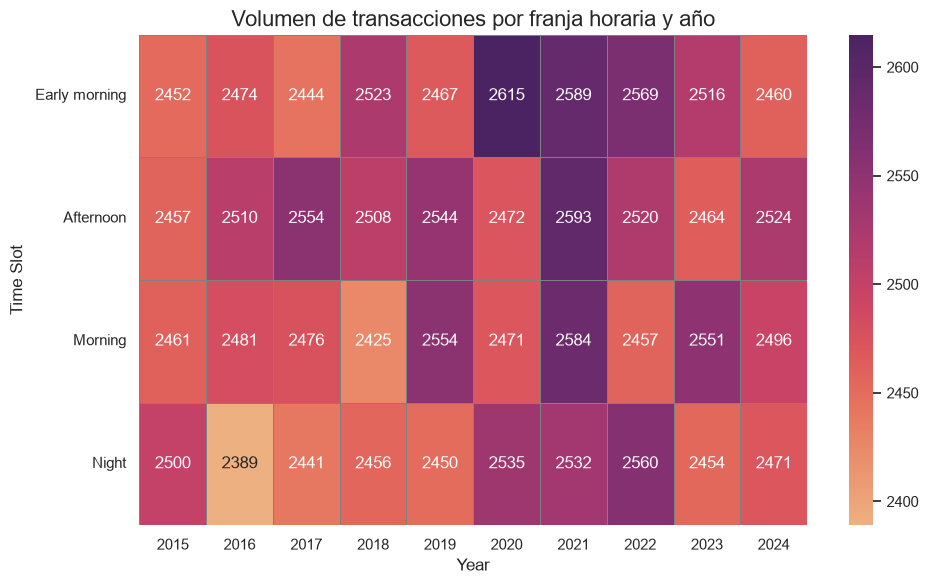

In [238]:
plt.figure(figsize=(10,6))
sns.color_palette("flare", as_cmap=True)
sns.heatmap(
    data=tabla_franjas,
    annot=True,  # mostrar el nº
    cmap="flare",
    fmt="d",
    linewidths=.5,   # lineas
    linecolor="gray", # color de las líneas
)


plt.title("Volumen de transacciones por franja horaria y año", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Time Slot")
plt.yticks(rotation=0) # Asegurar que los nombres de los meses estén horizontales
plt.tight_layout()
plt.show()

**CONCLUSIONES / INTERPRETACIÓN**

El mapa de calor permite identificar las franjas horarias con mayor actividad comercial y comprobar si esos patrones cambian a lo largo de los 9 años en los que tenemos registros.

La actividad de ventas varía muy poco según la franja horaria. Curiosamente, de madrugada se realizan más transacciones pero se ha de tener en cuenta que las horas cambian por países y que se ha realizado el análisis teniendo en cuenta solo un horario.

Además, este comportaniento no se mantiene estable conforme pasan los años asi que no veo una estrategia clara en cuanto a planificar ciertas campañas de marketing o push según horario.


---



# **NIVEL 2: ANÁLISIS RELACIONAL Y PATRONES AVANZADOS**

---

## **Ejercicio 1: Análisis de productos y captación de usuarios**

🎯 **Objetivo:** Analizar el rendimiento del producto combinando los ingresos, la estabilidad y la captación de nuevos usuarios, con el fin de identificar posibles riesgos empresariales asociados a una concentración excesiva de los ingresos, la dependencia de los usuarios recurrentes y la falta de crecimiento de la base de usuarios.


¿Los productos que generan más ingresos también impulsan el crecimiento del negocio mediante la captación de nuevos usuarios, o el negocio depende principalmente de que los usuarios habituales compren los mismos productos?


---

**Pasos a seguir:**

1. Combina las tablas necesarias.

2. Define un criterio de usuario nuevo si la transacción analizada es la primera que realizan cronológicamente en el sistema:
*   es_new_user = True / False.

3. Agrega la información por producto y calcula las siguientes métricas:

*   Ingresos totales.
*   Variabilidad de los ingresos.
*   Número de nuevos usuarios.
*   Porcentaje de nuevos usuarios respecto al total de compradores del producto.

4. Crea una tipología analítica de productos basada en las métricas calculadas, por ejemplo:

*   Adquirente: alta captación de nuevos usuarios.
*   Comprador habitual: altos ingresos pero baja captación.
*   Emergente: ingresos bajos pero buena captación.
*   Estancado: ingresos bajos y captación baja.
5. Crea una visualización que permita analizar la relación entre las dimensiones principales. Por ejemplo, un gráfico de dispersión con:

*   Eje X → ingresos totales por producto.
*   Eje Y → número de nuevos usuarios.
*   Tamaño del punto → variabilidad de los ingresos.
*   Color del punto → tipo de análisis del producto.

📌 Nota importante:

No se trata solo de mostrar gráficos, sino de interpretar qué significa para la empresa no captar nuevos usuarios.



**>> Combina las tablas necesarias.**

In [239]:
# Nos quedamos con las columnas necesarias
transactions_products = df_transactions[
    ["id", "user_id", "timestamp", "product_ids", "amount"]
].copy()

# Separar los productos como ya hemos hecho en el ejercicio anterior, no usamos la misma porque nocesitamos otras columnas
transactions_products["product_ids"] = (
    transactions_products["product_ids"]
    .str.split(", ")
)

# Una fila por producto
transactions_products = transactions_products.explode("product_ids")

# Convertir a entero
transactions_products["product_ids"] = (
    transactions_products["product_ids"].astype(int)
)

# Unir con productos
ventas_productos = pd.merge(
    transactions_products,
    df_products,
    left_on="product_ids",
    right_on="id",
    how="left"
)

In [240]:
ventas_productos.head()

,id_x,user_id,timestamp,product_ids,amount,id_y,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,4713,2024-08-28 07:16:46,16,433.51,16,the duel warden,180.91,#666666,3.0,WH-11,Home,NordHaus,101.11,2014-05-31
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,4713,2024-08-28 07:16:46,26,433.51,26,Stark Karstark,53.01,#898989,2.0,WH-21,Food,GreenFork,30.49,2013-02-15
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,4713,2024-08-28 07:16:46,97,433.51,97,jinn Winterfell,65.25,#bababa,1.0,WH-92,Beauty,CareLab,26.25,2013-02-22
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,4713,2024-08-28 07:16:46,87,433.51,87,sith Jade,96.26,#e2e2e2,2.0,WH-82,Food,Market&Co,66.36,2013-11-10
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,2118,2020-07-14 15:37:45,30,332.38,30,Karstark warden,79.53,#606060,1.0,WH-25,Electronics,Nexa,50.18,2013-02-06


**>> Define un criterio de usuario nuevo**

Si la transacción analizada es la primera que realizan cronológicamente en el sistema:
*   es_new_user = True / False.

💠 Prmero de todo necesitamos averiguar cuál es la primera compra de cada usuario.

In [241]:
# agrupapos por id de usuario y miramos cual el la fecha MIN de cada uno

primera_compra = (
    df_transactions
    .groupby("user_id")["timestamp"]
    .min()
    .reset_index()
)

# con esta nueva tabla que solo contiene el id de usuario y la fecha de la primera compra, cambiamos el nombre de la columna
primera_compra.rename(
    columns={"timestamp":"first_purchase"},
    inplace=True
)

In [242]:
primera_compra

,user_id,first_purchase
0,1,2015-05-08 18:09:41
1,10,2015-01-11 14:58:33
2,100,2015-07-04 15:27:15
3,1000,2015-11-23 03:48:02
4,1001,2015-03-25 00:48:32
...,...,...
4995,995,2015-01-03 18:01:41
4996,996,2015-04-11 17:39:11
4997,997,2015-05-20 20:43:07
4998,998,2015-01-05 06:17:11


💠 Combinamos esta nueva tabla de *primera compra* con la que ya habiamos creado de las transacciones con todos los produtos desglosados.

Si coincide la fecha de primera compra ➡ ahi será nuevo usuario, en el resto no. Asi podremos comprobar con qué producto fué captado este cliente.

In [243]:
# combinamos ambas tablas

ventas_productos = ventas_productos.merge(
    primera_compra,
    on="user_id",
    how="left"
)

In [244]:
# creamos una nuevo columna tal y como nos piden --> si en nuevo usuario o no teniendo en cuenta la feha de la primera compra

ventas_productos["is_new_user"] = (
    ventas_productos["timestamp"] ==
    ventas_productos["first_purchase"]
)

In [245]:
# comprobamos

ventas_productos[
    ["user_id","timestamp","first_purchase", "is_new_user"]
].head(5)

,user_id,timestamp,first_purchase,is_new_user
0,4713,2024-08-28 07:16:46,2015-02-06 02:39:31,False
1,4713,2024-08-28 07:16:46,2015-02-06 02:39:31,False
2,4713,2024-08-28 07:16:46,2015-02-06 02:39:31,False
3,4713,2024-08-28 07:16:46,2015-02-06 02:39:31,False
4,2118,2020-07-14 15:37:45,2015-08-03 18:53:18,False


**>> Agrega la información por producto y calcula las siguientes métricas**

*   Ingresos totales.
*   Variabilidad de los ingresos.
*   Número de nuevos usuarios.
*   Porcentaje de nuevos usuarios respecto al total de compradores del producto.


---



💠 Utilizaremos la columna de *id del producto* y no la de nombre porque los ids son únicos, ya que he podido ver que los nombres de los productos estan escritos de diferentes formas y puede hacer agrupaciones erróneas.

*   Ingresos totales ➡ Sumamos el importe de todas las ventas
*   Variabilidad de los ingresos ➡ calculamos la media y la desviación para después usarlos en otra columna calculada.
*   Número de nuevos usuarios ➡ contamos True (sumar True = 1)
*   Porcentaje de nuevos usuarios respecto al total de compradores del producto ➡ calculamos cuantos usuarios únicos han comprado el producto para luego hacer el cálculo con los nuevos usuarios.

In [246]:
calcular_metricas = ventas_productos.groupby("product_ids").agg(
    total_amount = ("amount", "sum"),
    mean_amount = ("amount", "mean"),
    std_amount = ("amount", "std"),
    new_users = ("is_new_user", "sum"),
    total_users = ("user_id", "nunique")
).reset_index() # si no, sales los ids como index y puede llevar a cofusión

In [247]:
calcular_metricas.head(5)

,product_ids,total_amount,mean_amount,std_amount,new_users,total_users
0,1,1015105.09,411.306763,151.738468,108,1901
1,2,638149.57,248.017711,148.337179,126,1963
2,3,1079086.36,426.853782,154.384651,126,1933
3,4,818632.36,316.808189,147.988552,122,1956
4,5,1078063.70,423.101923,151.308797,152,1943


💠 Ahora, necesitamos añadir la variabilidad de los ingresos:

          variabilidad = (desviación / promedio) * 100

In [248]:
calcular_metricas["variability"] = (calcular_metricas["std_amount"] / calcular_metricas["mean_amount"])*100

In [249]:
calcular_metricas.head(5)

,product_ids,total_amount,mean_amount,std_amount,new_users,total_users,variability
0,1,1015105.09,411.306763,151.738468,108,1901,36.891800
1,2,638149.57,248.017711,148.337179,126,1963,59.809107
2,3,1079086.36,426.853782,154.384651,126,1933,36.168041
3,4,818632.36,316.808189,147.988552,122,1956,46.712351
4,5,1078063.70,423.101923,151.308797,152,1943,35.761784


💠 Añadimos otra columna calculada con el porcentaje de nuevos usuarios respecto al total de compradores del producto:

          % nuevos usuarios = (nuevos usuarios / total usuarios) * 100

In [250]:
calcular_metricas["%new_users"] = (calcular_metricas["new_users"] / calcular_metricas["total_users"])*100

In [251]:
calcular_metricas.head(5)

,product_ids,total_amount,mean_amount,std_amount,new_users,total_users,variability,%new_users
0,1,1015105.09,411.306763,151.738468,108,1901,36.891800,5.681220
1,2,638149.57,248.017711,148.337179,126,1963,59.809107,6.418747
2,3,1079086.36,426.853782,154.384651,126,1933,36.168041,6.518365
3,4,818632.36,316.808189,147.988552,122,1956,46.712351,6.237219
4,5,1078063.70,423.101923,151.308797,152,1943,35.761784,7.822954


**>> Crea una tipología analítica de productos basada en las métricas calculadas**

* Adquirente: alta captación de nuevos usuarios.
* Comprador habitual: altos ingresos pero baja captación.
* Emergente: ingresos bajos pero buena captación.
* Estancado: ingresos bajos y captación baja.

---

💠 Crearemos una función que nos clasifique a los usuarios en estas 4 categorías. Pero primero debemos establecer cuáles son los criterios de de este *clustering*.

💠 Medida de referencia ➡ media que ya tenemos calculada.


In [252]:
mean_amount = calcular_metricas["total_amount"].median()
mean_newusers = calcular_metricas["%new_users"].median()

def product_clasification(fila):

  if (
    fila["total_amount"] >= mean_amount
    and
    fila["%new_users"] >= mean_newusers):
    return "New Customer"

  elif (
    fila["total_amount"] >= mean_amount
    and
    fila["%new_users"] < mean_newusers):
    return "Regular Customer"

  elif (
    fila["total_amount"] < mean_amount
    and
    fila["%new_users"] >= mean_newusers):
    return "Emerging"

  else:
    return "Stagnant"


💠 Aplicamos esta función que nos creará una nueva columna con el resultado de la calsificación.

In [253]:
calcular_metricas["tipology"] = calcular_metricas.apply(
    product_clasification,
    axis=1
)

In [254]:
calcular_metricas.head(5)

,product_ids,total_amount,mean_amount,std_amount,new_users,total_users,variability,%new_users,tipology
0,1,1015105.09,411.306763,151.738468,108,1901,36.891800,5.681220,Regular Customer
1,2,638149.57,248.017711,148.337179,126,1963,59.809107,6.418747,Stagnant
2,3,1079086.36,426.853782,154.384651,126,1933,36.168041,6.518365,New Customer
3,4,818632.36,316.808189,147.988552,122,1956,46.712351,6.237219,Stagnant
4,5,1078063.70,423.101923,151.308797,152,1943,35.761784,7.822954,New Customer


**>> Crea una visualización que permita analizar la relación entre las dimensiones principales.**

Por ejemplo, un gráfico de dispersión con:

*   Eje X → ingresos totales por producto.
*   Eje Y → número de nuevos usuarios.
*   Tamaño del punto → variabilidad de los ingresos.
*   Color del punto → tipo de análisis del producto.

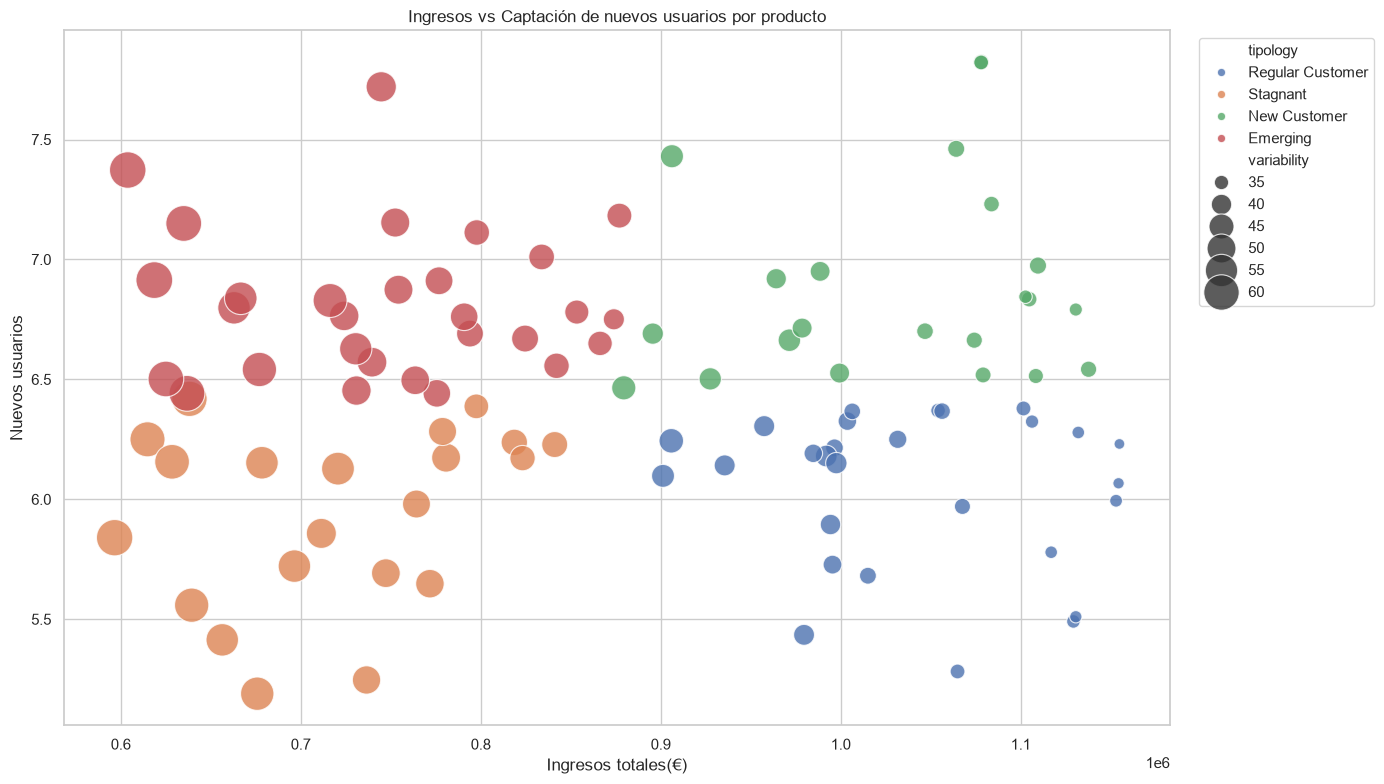

In [255]:
plt.figure(figsize=(14,8))

sns.scatterplot(
    data=calcular_metricas,
    x="total_amount",
    y="%new_users",
    hue="tipology",
    size="variability",
    sizes=(60,700),
    alpha=0.8
)

plt.title("Ingresos vs Captación de nuevos usuarios por producto")

plt.xlabel("Ingresos totales(€)")

plt.ylabel("Nuevos usuarios")

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.show()



---

**CONCLUSIONES**

Los productos que generan más ingresos son los azules, es decir, los clientes regulares. Es decir, la empresa tiene una buena red de clientes fieles.

Hay muy pocos productos que atraen nuevos usuarios, aunque generan un top de ingresos.

Los productos que generan nuevos clientes (en rojo) son los que menos ingresos producen, además de que la variablidad de los ingresos de los productos en más amplia. Quizá son clientes nuevos que buscan ofertas y no tanto una fidelidad.

Obviamente, los productos que proporcionan clientes estancados son aquellos con mayor varibilidad de ingresos. Pueden que sean clientes esporádicos que solo entrar a buscar un prodcuto en oferta concreto o fruto de una acción de marketing.


---




##⚡ ¿Los productos que generan más ingresos también impulsan el crecimiento del negocio mediante la captación de nuevos usuarios, o el negocio depende principalmente de que los usuarios habituales compren los mismos productos?⚡


**La empresa depende principalmente de los clientes reguales y no de la captación de nuevos usuarios.**

Los productos que más facturan son justamente los que tienen menor porcentaje  de captación de nuevos usuarios. Sin embargo, los productos que sí traen usuarios nuevos generan ingresos más bajos.


Esto puede ser un problema a largo plazo en la empresa ya que depender siempre de los mismos clientes es peligroso. El crecimiento de ingresos y crecimiento de nuevos usuarios debe ir alineado y se debe estudiar una manera de captación y retención que no sea tan fluctuante y basada en la variación del precio del producto.



---

## **Ejercicio 2: Análisis geográfico de la relación empresa-usuario y oportunidades de expansión**

🎯 **Objetivo:** Analizar la relación entre el país de las empresas vendedoras, el país de residencia de los usuarios y el flujo de compras transfronterizas.


¿El negocio se basa en los mercados locales (usuario y empresa del mismo país), o existe una oportunidad real de expansión internacional mediante la apertura de más empresas en determinados países?


---

**Pasos a seguir:**

1. Combina las tablas necesarias.

2. Crea una variable clave de análisis: compra_local = Verdadero/Falso.

3. Analiza el comportamiento general:

* Porcentaje de transacciones locales frente a internacionales.
* Porcentaje de ingresos locales frente a internacionales.

4. Analiza por país de origen del usuario; para cada país de origen:

* % de compras a empresas del mismo país.
* % de compras a empresas extranjeras.
* Importe total de las compras.

5. Análisis por país de la empresa: para cada país de la empresa, calcula qué proporción de su facturación procede de:

* Usuarios locales.
* Usuarios extranjeros.

6. Elige una visualización que explique claramente el fenómeno.

7. Interpretación estratégica:

* ¿En qué países valdría la pena abrir más empresas locales?
* ¿Hay países con demanda pero con poca oferta local?
* ¿Depende demasiado el negocio de empresas de un único país?
* ¿La apertura de empresas locales reduciría la fricción o mejoraría la conversión?



---

**>> Combinar las tablas necesarias.**

💠Necesitaremos 3 tablas:
* users ➡ user_id
* transactions ➡ user_id + business_id
* companies ➡ company_id

💠 No necesitamos todas las tablas al completo, combinar todo nos daría una dataframe muy extenso. Debemos seleccionar las columnas de cada una que nos sirvan para resolver el enunciado.


In [256]:
# TRANSACTIONS

# Configurar la conexión al localhost
conexion = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234",
    database="product_transactions"
)

# consulta tabla
transactions = "SELECT id, business_id, amount, user_id FROM transactions;"

# Cargar los datos directamente en un DataFrame de Pandas
transactions = pd.read_sql(transactions, conexion)


# Mostrar los resultados
transactions.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_20804\2703291562.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions = pd.read_sql(transactions, conexion)


,id,business_id,amount,user_id
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,433.51,4713
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,332.38,2118
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,b-2230,175.00,2115
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,b-2266,158.55,3025
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,b-2598,317.97,215


In [257]:
# COMPANIES

# consulta tabla
companies = "SELECT company_id, company_name, country FROM companies;"

# Cargar los datos directamente en un DataFrame de Pandas
df_companies = pd.read_sql(companies, conexion)

# Mostrar los resultados
df_companies.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_20804\4110331910.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_companies = pd.read_sql(companies, conexion)


,company_id,company_name,country
0,b-2222,Ac Fermentum Incorporated,Germany
1,b-2226,Magna A Neque Industries,Australia
2,b-2230,Fusce Corp.,United States
3,b-2234,Convallis In Incorporated,Germany
4,b-2238,Ante Iaculis Nec Foundation,New Zealand


In [258]:
# USERS
users = "SELECT user_id, country, origin FROM users;"

# Cargar los datos directamente en un DataFrame de Pandas
df_users = pd.read_sql(users, conexion)

# Cerrar la conexión
conexion.close()

# Mostrar los resultados
df_users.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_20804\1828720603.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_users = pd.read_sql(users, conexion)


,user_id,country,origin
0,1,United States,USA
1,10,United States,USA
2,100,United States,USA
3,1006,United States,USA
4,101,United States,USA


💠 Renombramos las columnas, por ejemplo, necesitamos el país de la compañia y es país del usuario, que no se solapen.

In [259]:
transactions = transactions.rename(
    columns={
        "id": "transaction_id",
        "business_id": "company_id",
        "amount": "transaction_amount",
        "user_id": "user_id"})

In [260]:
df_companies = df_companies.rename(
    columns={
        "company_id": "company_id",
        "company_name": "company_name",
        "country": "company_country"})

In [261]:
df_users = df_users.rename(
    columns={
        "user_id": "user_id",
        "country": "user_country",
        "origin": "user_origin"})

💠 Combinamos *transactions* y users con *user_id*

In [262]:
df_complet = pd.merge(
    transactions,
    df_users,
    on="user_id",
    how="left"
)

💠 Combinamos este df creado con *companies* con *company_id*

In [263]:
df_complet = pd.merge(
    df_complet,
    df_companies,
    on="company_id",
    how="left"
)


**>> Crea una variable clave de análisis**

    compra_local = Verdadero/Falso

In [264]:
def compra_local(fila):
  if fila["user_country"] == fila["company_country"]:
    return True
  else:
    return False

In [265]:
df_complet["local_sale"] = df_complet.apply(
    compra_local,
    axis=1)

In [266]:
# comprobamos
df_complet

,transaction_id,company_id,transaction_amount,user_id,user_country,user_origin,company_name,company_country,local_sale
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,433.51,4713,France,EU,Eget Tincidunt Dui Institute,Netherlands,False
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,332.38,2118,United States,USA,Neque Tellus Imperdiet Corp.,Ireland,False
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,b-2230,175.00,2115,Canada,USA,Fusce Corp.,United States,False
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,b-2266,158.55,3025,Netherlands,EU,Mus Aenean Eget Foundation,Sweden,False
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,b-2598,317.97,215,Canada,USA,Aliquam Iaculis Lacus Corp.,Belgium,False
...,...,...,...,...,...,...,...,...,...
99994,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,b-2234,278.42,429,Germany,EU,Convallis In Incorporated,Germany,True
99995,FFFB270D-F53A-4D5D-9666-E5307C53CC84,b-2522,403.66,3074,Portugal,EU,Viverra Donec Foundation,United Kingdom,False
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,295.43,1008,Sweden,EU,Nunc Interdum Incorporated,Germany,False
99997,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,b-2250,183.02,680,Netherlands,EU,Amet Nulla Donec Corporation,Italy,False


**>> Analiza el comportamiento general**

* Porcentaje de transacciones locales frente a internacionales.
* Porcentaje de ingresos locales frente a internacionales.

💠 Contamos las transacciones locales
💠 Contamos las transacciones internacionales
💠 Contamos todas las transacciones

In [267]:
import pandas as pd

In [268]:
comportamiento_general = df_complet.groupby("local_sale").agg(
    amount = ("transaction_amount", "sum"),
    transactions = ("transaction_id", "count")
).reset_index() # si no, salen los ids como index y puede llevar a cofusión

In [269]:
comportamiento_general

,local_sale,amount,transactions
0,False,25818609.52,88137
1,True,3476692.27,11862


In [270]:
# calculamos el total de transacciones y de ingresos para despues realizar el porcentaje

total_amount = comportamiento_general["amount"].sum()
total_transactions = comportamiento_general["transactions"].sum()

In [271]:
print(f"Total de ingresos: {total_amount} €.")
print(f"Total de transacciones: {total_transactions}")

Total de ingresos: 29295301.79 €.
Total de transacciones: 99999


In [272]:
comportamiento_general["perc_transactions"] = (comportamiento_general["transactions"] / total_transactions)*100
comportamiento_general["perc_amount"] = (comportamiento_general["amount"] / total_amount)*100

In [273]:
comportamiento_general

,local_sale,amount,transactions,perc_transactions,perc_amount
0,False,25818609.52,88137,88.137881,88.132253
1,True,3476692.27,11862,11.862119,11.867747


🚩 El porcentaje de ambas columnas coincide, no es es un error de calculo, lo he calculado varias veces. Se trata de unos datos ficticios y es pobable que por esta razón coincida.

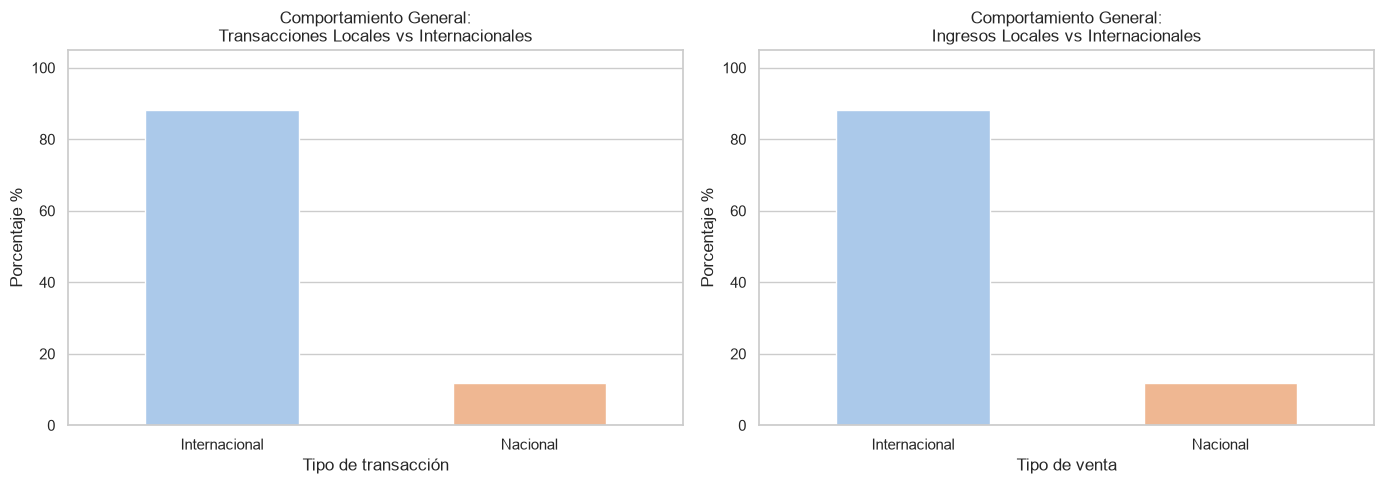

In [274]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# gráfico 1
sns.barplot(
    data=comportamiento_general,
    x="local_sale",
    y="perc_transactions",
    hue="local_sale",
    width=0.5,
    palette="pastel",
    ax=axes[0],
    legend=False
)

axes[0].set_ylim(0, 105)
axes[0].set_title(
    "Comportamiento General:\nTransacciones Locales vs Internacionales"
)
axes[0].set_xlabel("Tipo de transacción")
axes[0].set_ylabel("Porcentaje %")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Internacional", "Nacional"])


# gráfico 2
sns.barplot(
    data=comportamiento_general,
    x="local_sale",
    y="perc_amount",
    hue="local_sale",
    width=0.5,
    palette="pastel",
    ax=axes[1],
    legend=False
)

axes[1].set_ylim(0, 105)
axes[1].set_title("Comportamiento General:\nIngresos Locales vs Internacionales")
axes[1].set_xlabel("Tipo de venta")
axes[1].set_ylabel("Porcentaje %")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Internacional", "Nacional"])


plt.tight_layout()

plt.show()


**CONCLUSIONES ANÁLITICAS:**

Vemos que el porcentaje de ventas y transacciones internaciones predomina en la empresa por lo que hay una gran dependencia del mercado internacional.

Si comparamos  el gráfico de la izquierda (transacciones) con el de la derecha (ingresos), las dimensiones de las barras son exáctamente iguales.

El mercado local no está explotado.

---

**>> Analiza por país de origen del usuario; para cada país de origen:**

* % de compras a empresas del mismo país.
* % de compras a empresas extranjeras.
* Importe total de las compras.


💠Agruparemos en un dataframe nuevo las ventas y las transacciones por páis de usuario.

In [275]:
analisis_usuario = (
    df_complet
    .groupby(
        ["user_country","local_sale"]
    )
    .agg(
        sales = ("transaction_id","count"),
        amount = ("transaction_amount","sum")
    )
    .reset_index()
)

In [276]:
#comprobamos

analisis_usuario

,user_country,local_sale,sales,amount
0,Canada,False,9016,2431103.55
1,Canada,True,970,257837.28
2,France,False,7972,2334648.67
3,France,True,534,154348.57
4,Germany,False,7245,2125863.60
5,Germany,True,1478,447388.07
6,Italy,False,7100,2159920.60
7,Italy,True,1465,443472.57
8,Netherlands,False,7230,2153772.47
9,Netherlands,True,1731,521393.18


💠 Se ha generado una nueva tabla pero tenemos 2 lineas por cada país, nacionales e internaciones. Lo vamos a unicifcar, haremos una fila por cada país, después será más fácil calcular el porcentaje y visualizar los datos.

In [277]:
# creamos la tabla
resumen_usuario = (analisis_usuario.pivot(
        index="user_country",
        columns="local_sale",
        values=["sales", "amount"]))


In [278]:
# sustituimos los valores vacios "NaN" en 0 para que luego el proentaje se pueda calcular correctamente
resumen_usuario = resumen_usuario.fillna(0)

In [279]:
# comprobamos
resumen_usuario

sales              amount           
local_sale       False   True        False      True 
user_country                                         
Canada          9016.0   970.0  2431103.55  257837.28
France          7972.0   534.0  2334648.67  154348.57
Germany         7245.0  1478.0  2125863.60  447388.07
Italy           7100.0  1465.0  2159920.60  443472.57
Netherlands     7230.0  1731.0  2153772.47  521393.18
Poland          8274.0     0.0  2512973.74       0.00
Portugal        8765.0     0.0  2638023.31       0.00
Spain           8804.0   156.0  2644341.02   49225.22
Sweden          6387.0  1729.0  1962304.41  528506.31
United Kingdom  7979.0  1668.0  2347379.22  491510.15
United States   9365.0  2131.0  2508278.93  583010.92

In [280]:
# renombramos las columnas
resumen_usuario.columns = [
    "int_tx",
    "nat_tx",
    "int_revenue",
    "nat_revenue"]



In [281]:
# Como habia columnas sin valores (NaN) debemos reconvertir a numérico las columnas, más tarde será necesario para hacer los cálculos

resumen_usuario["nat_tx"] = resumen_usuario["nat_tx"].astype(int)
resumen_usuario["int_tx"] = resumen_usuario["int_tx"].astype(int)

resumen_usuario["nat_revenue"] = resumen_usuario["nat_revenue"].astype(float)
resumen_usuario["int_revenue"] = resumen_usuario["int_revenue"].astype(float)

In [282]:
# comprobamos que se han hecho los cambios
resumen_usuario

,int_tx,nat_tx,int_revenue,nat_revenue
user_country,,,,
Canada,9016,970,2431103.55,257837.28
France,7972,534,2334648.67,154348.57
Germany,7245,1478,2125863.60,447388.07
Italy,7100,1465,2159920.60,443472.57
Netherlands,7230,1731,2153772.47,521393.18
Poland,8274,0,2512973.74,0.00
Portugal,8765,0,2638023.31,0.00
Spain,8804,156,2644341.02,49225.22
Sweden,6387,1729,1962304.41,528506.31


In [283]:
# convertimos el índice en la primera columna
resumen_usuario = resumen_usuario.reset_index()

# comprobamos
resumen_usuario

,user_country,int_tx,nat_tx,int_revenue,nat_revenue
0,Canada,9016,970,2431103.55,257837.28
1,France,7972,534,2334648.67,154348.57
2,Germany,7245,1478,2125863.60,447388.07
3,Italy,7100,1465,2159920.60,443472.57
4,Netherlands,7230,1731,2153772.47,521393.18
5,Poland,8274,0,2512973.74,0.00
6,Portugal,8765,0,2638023.31,0.00
7,Spain,8804,156,2644341.02,49225.22
8,Sweden,6387,1729,1962304.41,528506.31
9,United Kingdom,7979,1668,2347379.22,491510.15


In [284]:
# añadimos una columna con el total de las transacciones e ingresos por país

resumen_usuario["total_sales"] = resumen_usuario["int_tx"] + resumen_usuario["nat_tx"]
resumen_usuario["total_revenue"] = resumen_usuario["int_revenue"] + resumen_usuario["nat_revenue"]

In [285]:
# comprobamos
resumen_usuario

,user_country,int_tx,nat_tx,int_revenue,nat_revenue,total_sales,total_revenue
0,Canada,9016,970,2431103.55,257837.28,9986,2688940.83
1,France,7972,534,2334648.67,154348.57,8506,2488997.24
2,Germany,7245,1478,2125863.60,447388.07,8723,2573251.67
3,Italy,7100,1465,2159920.60,443472.57,8565,2603393.17
4,Netherlands,7230,1731,2153772.47,521393.18,8961,2675165.65
5,Poland,8274,0,2512973.74,0.00,8274,2512973.74
6,Portugal,8765,0,2638023.31,0.00,8765,2638023.31
7,Spain,8804,156,2644341.02,49225.22,8960,2693566.24
8,Sweden,6387,1729,1962304.41,528506.31,8116,2490810.72
9,United Kingdom,7979,1668,2347379.22,491510.15,9647,2838889.37


💠 Para que el porcentaje y el dataframe sea más claro, reordenamos las columnas: primero toda la información relacionada a las trasnferencia y después al importe

In [286]:
resumen_usuario = resumen_usuario[
    [
        "user_country",
        "int_tx",
        "nat_tx",
        "total_sales",
        "int_revenue",
        "nat_revenue",
        "total_revenue",
    ]
]

In [287]:
resumen_usuario

,user_country,int_tx,nat_tx,total_sales,int_revenue,nat_revenue,total_revenue
0,Canada,9016,970,9986,2431103.55,257837.28,2688940.83
1,France,7972,534,8506,2334648.67,154348.57,2488997.24
2,Germany,7245,1478,8723,2125863.60,447388.07,2573251.67
3,Italy,7100,1465,8565,2159920.60,443472.57,2603393.17
4,Netherlands,7230,1731,8961,2153772.47,521393.18,2675165.65
5,Poland,8274,0,8274,2512973.74,0.00,2512973.74
6,Portugal,8765,0,8765,2638023.31,0.00,2638023.31
7,Spain,8804,156,8960,2644341.02,49225.22,2693566.24
8,Sweden,6387,1729,8116,1962304.41,528506.31,2490810.72
9,United Kingdom,7979,1668,9647,2347379.22,491510.15,2838889.37


In [288]:
resumen_usuario["perc_nat_sales"] = (resumen_usuario["nat_tx"] / resumen_usuario["total_sales"])*100
resumen_usuario["perc_int_sales"] = (resumen_usuario["int_tx"] / resumen_usuario["total_sales"])*100

In [289]:
resumen_usuario["perc_nat_revenue"] = (resumen_usuario["nat_revenue"] / resumen_usuario["total_revenue"])*100
resumen_usuario["perc_int_revenue"] = (resumen_usuario["int_revenue"] / resumen_usuario["total_revenue"])*100


In [290]:
# comprobamos
resumen_usuario

,user_country,int_tx,nat_tx,total_sales,int_revenue,nat_revenue,total_revenue,perc_nat_sales,perc_int_sales,perc_nat_revenue,perc_int_revenue
0,Canada,9016,970,9986,2431103.55,257837.28,2688940.83,9.713599,90.286401,9.588805,90.411195
1,France,7972,534,8506,2334648.67,154348.57,2488997.24,6.277921,93.722079,6.201235,93.798765
2,Germany,7245,1478,8723,2125863.60,447388.07,2573251.67,16.943712,83.056288,17.386099,82.613901
3,Italy,7100,1465,8565,2159920.60,443472.57,2603393.17,17.104495,82.895505,17.034406,82.965594
4,Netherlands,7230,1731,8961,2153772.47,521393.18,2675165.65,19.317041,80.682959,19.490127,80.509873
5,Poland,8274,0,8274,2512973.74,0.00,2512973.74,0.000000,100.000000,0.000000,100.000000
6,Portugal,8765,0,8765,2638023.31,0.00,2638023.31,0.000000,100.000000,0.000000,100.000000
7,Spain,8804,156,8960,2644341.02,49225.22,2693566.24,1.741071,98.258929,1.827511,98.172489
8,Sweden,6387,1729,8116,1962304.41,528506.31,2490810.72,21.303598,78.696402,21.218245,78.781755
9,United Kingdom,7979,1668,9647,2347379.22,491510.15,2838889.37,17.290349,82.709651,17.313466,82.686534


In [291]:
del resumen_usuario["total_sales"]
del resumen_usuario["total_revenue"]

In [292]:
# comprobamos
resumen_usuario

,user_country,int_tx,nat_tx,int_revenue,nat_revenue,perc_nat_sales,perc_int_sales,perc_nat_revenue,perc_int_revenue
0,Canada,9016,970,2431103.55,257837.28,9.713599,90.286401,9.588805,90.411195
1,France,7972,534,2334648.67,154348.57,6.277921,93.722079,6.201235,93.798765
2,Germany,7245,1478,2125863.60,447388.07,16.943712,83.056288,17.386099,82.613901
3,Italy,7100,1465,2159920.60,443472.57,17.104495,82.895505,17.034406,82.965594
4,Netherlands,7230,1731,2153772.47,521393.18,19.317041,80.682959,19.490127,80.509873
5,Poland,8274,0,2512973.74,0.00,0.000000,100.000000,0.000000,100.000000
6,Portugal,8765,0,2638023.31,0.00,0.000000,100.000000,0.000000,100.000000
7,Spain,8804,156,2644341.02,49225.22,1.741071,98.258929,1.827511,98.172489
8,Sweden,6387,1729,1962304.41,528506.31,21.303598,78.696402,21.218245,78.781755
9,United Kingdom,7979,1668,2347379.22,491510.15,17.290349,82.709651,17.313466,82.686534


💠 Visualización de estos datos.

* % de compras a empresas del mismo país.
* % de compras a empresas extranjeras.
* Importe total de las compras.


He elegido un gráfico de barras aplicadas que nos permitirá ver el porcentaje de cada una de las comparas de una manera muy visual.

Añadiremos un gráfico de líneas para ver la evolución total de los importes.

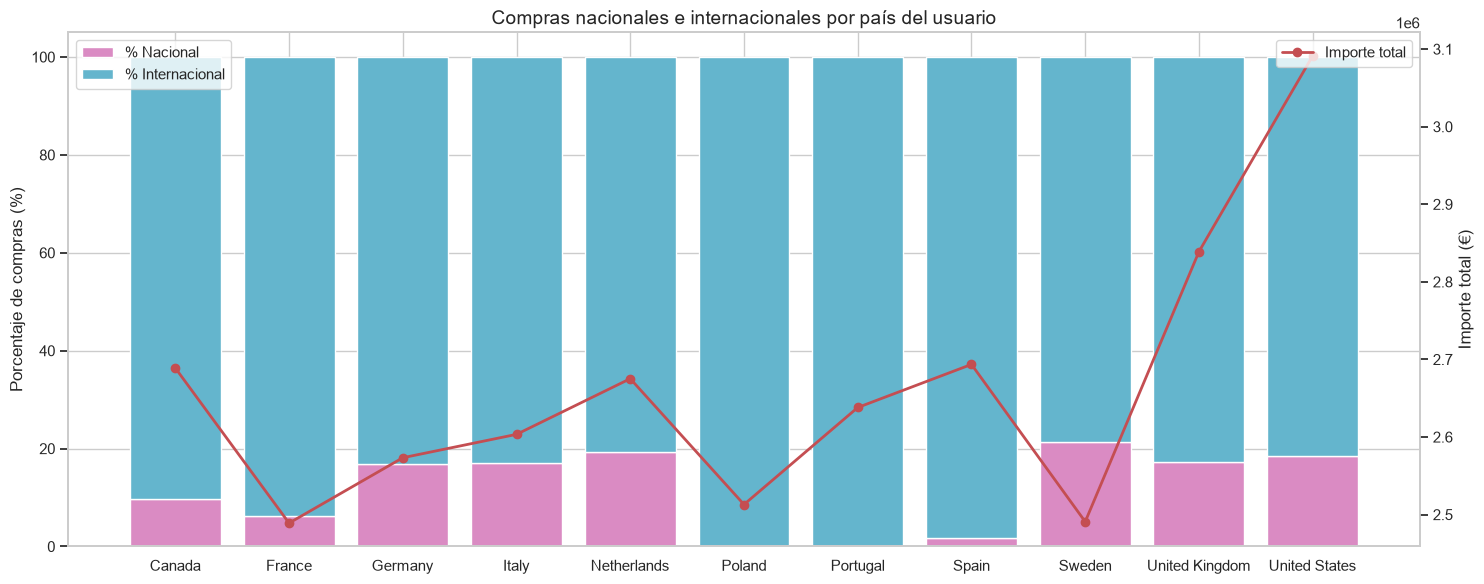

In [293]:
fig, ax1 = plt.subplots(figsize=(15,6))

# primer eje con los porcentajes
ax1.bar(
    resumen_usuario["user_country"],
    resumen_usuario["perc_nat_sales"],
    label="% Nacional",
    color="C6"
)

ax1.bar(
    resumen_usuario["user_country"],
    resumen_usuario["perc_int_sales"],
    bottom=resumen_usuario["perc_nat_sales"],
    label="% Internacional",
    color="C9"
)

ax1.set_ylabel("Porcentaje de compras (%)")
ax1.set_ylim(0,105)

# Segundo eje con los ingresos totales
ax2 = ax1.twinx()

ax2.plot(
    resumen_usuario["user_country"],
    resumen_usuario["int_revenue"] + resumen_usuario["nat_revenue"],
    color="r",
    marker="o",
    linewidth=2,
    label="Importe total"
)

ax2.set_ylabel("Importe total (€)")

plt.title("Compras nacionales e internacionales por país del usuario", fontsize=14)

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")


ax2.grid(False)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**CONCLUSIONES ANÁLITICAS:**

Podemos ver que la tendencia del usuario es comprar a empresas extranjeras. Me parece un dato curiosos y digno de analizar. ¿por qué esta tendencia tan marcada?

Habría que preguntarse si los clientes tienen los que necesitan en las empresas del mismo país o la cantidad de empesas del mismo.

Polonia y Portugal n o hacen ninguna compara en el mismo páis, este caso puede ser porque no hay empresas en el país en si.

Algo similar puede pasar en España ¿cuántas empresas hay en España?

En referencia al importe total de las ventas, vemos que las empresas más rentables están en EEUU, sin embargo, el rango no es tan distante, solo 500k.
Se podría analizar que consumen los clientes en esas empresas e implementarlo en el resto.

---

**>> Análisis por país de la empresa: para cada país de la empresa, calcula qué proporción de su facturación procede de:**

* Usuarios locales.
* Usuarios extranjeros


💠Agruparemos en un dataframe por país de empresa: ventas locales e internacionales.

In [294]:
analisis_empresa = (
    df_complet
    .groupby(
        ["company_country","local_sale"]
    )
    .agg(
        revenue=("transaction_amount","sum")
    )
    .reset_index()
)

In [295]:
analisis_empresa

,company_country,local_sale,revenue
0,Australia,False,699013.06
1,Belgium,False,952208.75
2,Canada,False,300731.48
3,Canada,True,257837.28
4,China,False,239034.47
5,France,False,1261735.69
6,France,True,154348.57
7,Germany,False,3572976.00
8,Germany,True,447388.07
9,Ireland,False,715220.46


💠 Calculamos el porcentaje de cada tipo de trasnaccion: nacional e internacional.

In [296]:
analisis_empresa["percentagte"] = (
    analisis_empresa.groupby("company_country")["revenue"]
    .transform(lambda x:x/x.sum()*100)
)

In [297]:
analisis_empresa

,company_country,local_sale,revenue,percentagte
0,Australia,False,699013.06,100.000000
1,Belgium,False,952208.75,100.000000
2,Canada,False,300731.48,53.839653
3,Canada,True,257837.28,46.160347
4,China,False,239034.47,100.000000
5,France,False,1261735.69,89.100326
6,France,True,154348.57,10.899674
7,Germany,False,3572976.00,88.871951
8,Germany,True,447388.07,11.128049
9,Ireland,False,715220.46,100.000000


💠 Modificamos la tabla para que hay una sola fila por país.

In [298]:
analisis_empresa = pd.crosstab(
    df_complet["company_country"],
    df_complet["local_sale"],
    normalize="index"
) *100

In [299]:
analisis_empresa

local_sale,False,True
company_country,,
Australia,100.000000,0.000000
Belgium,100.000000,0.000000
Canada,53.962981,46.037019
China,100.000000,0.000000
France,88.638298,11.361702
Germany,88.879693,11.120307
Ireland,100.000000,0.000000
Italy,89.281534,10.718466
Netherlands,88.502159,11.497841


In [300]:
# convertimos el índice en la primera columna
analisis_empresa = analisis_empresa.reset_index()

# comprobamos
analisis_empresa

local_sale,company_country,False,True
0,Australia,100.000000,0.000000
1,Belgium,100.000000,0.000000
2,Canada,53.962981,46.037019
3,China,100.000000,0.000000
4,France,88.638298,11.361702
5,Germany,88.879693,11.120307
6,Ireland,100.000000,0.000000
7,Italy,89.281534,10.718466
8,Netherlands,88.502159,11.497841
9,New Zealand,100.000000,0.000000


In [301]:
# renombramos las columnas
analisis_empresa.columns = [
    "company_country",
    "%int_users",
    "%nat_users"]

analisis_empresa

,company_country,%int_users,%nat_users
0,Australia,100.000000,0.000000
1,Belgium,100.000000,0.000000
2,Canada,53.962981,46.037019
3,China,100.000000,0.000000
4,France,88.638298,11.361702
5,Germany,88.879693,11.120307
6,Ireland,100.000000,0.000000
7,Italy,89.281534,10.718466
8,Netherlands,88.502159,11.497841
9,New Zealand,100.000000,0.000000


💠 Visualizamos.

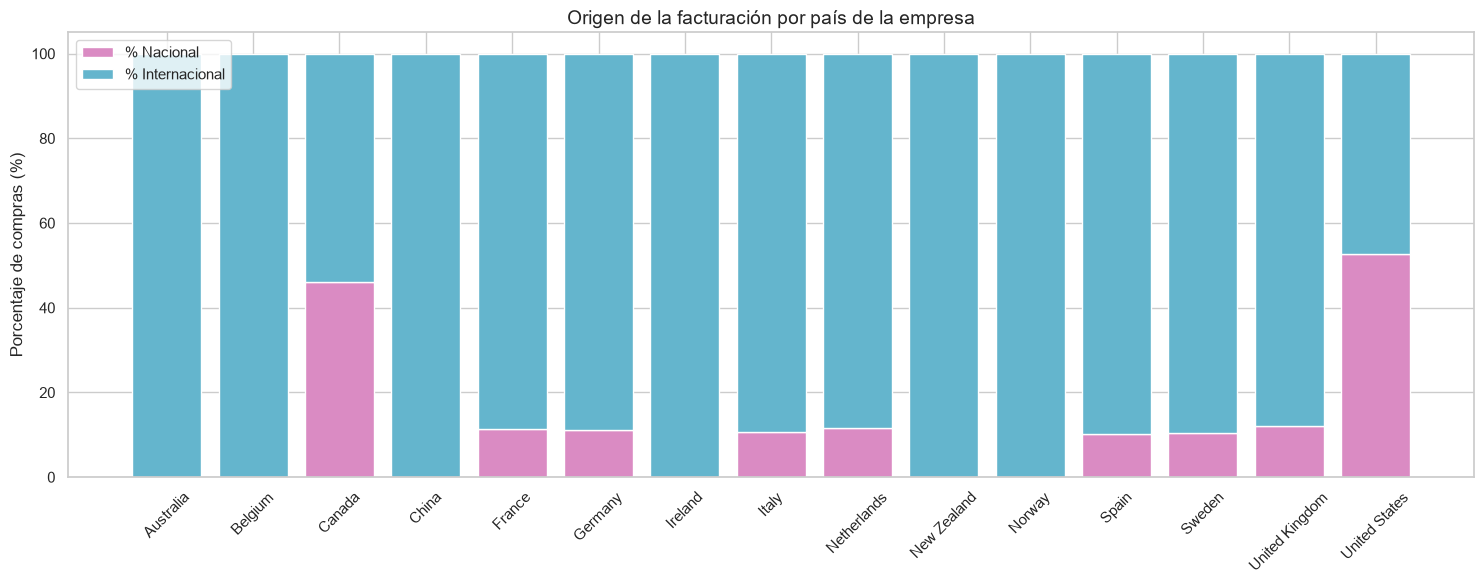

In [302]:
fig, ax1 = plt.subplots(figsize=(15,6))

# primer eje con los porcentajes
ax1.bar(
    analisis_empresa["company_country"],
    analisis_empresa["%nat_users"],
    label="% Nacional",
    color="C6"
)

ax1.bar(
    analisis_empresa["company_country"],
    analisis_empresa["%int_users"],
    bottom=analisis_empresa["%nat_users"],
    label="% Internacional",
    color="C9"
)

ax1.set_ylabel("Porcentaje de compras (%)")
ax1.set_ylim(0,105)


plt.title("Origen de la facturación por país de la empresa", fontsize=14)

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")


ax2.grid(False)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**>> INTERPRETACIÓN ESTRATÉGICA**

##⚡ **¿En qué países valdría la pena abrir más empresas locales?**


En aquellos países en lo cuales su facturación depende mayoritariamente de los clientes extranjeros. Es arriesgado depender de ellos ya que las leyes, aduanas, impuestos, etc pueden variar y perjudicar al negocio. Si la dependencia local es más amplia es más facil sostener la rentabilidad a largo plazo.

---

##⚡ **¿Hay países con demanda pero con poca oferta local?**

Si, un ejemplo claro es Polonia y Portugal, no disponen de empresas locales por lo que los clientes necesitan 100% comprar en empresas extranjeras. pero la demanda existe. Analizar qué productos buscan y enforcarse en priorizar abrir empresas enfocadas a esos productos.

Por otro lado, están los clientes de España donde hay poca empresa local. El 98% de los usuarios compran en empresas internacionales, pero hay un interés de compra en empresas nacionales, auqnue existen muy pocas.

---


##⚡ **¿Depende demasiado el negocio de empresas de un único país?**

No depende de un único país pero si que una parte importante de los ingresos procede de unos pocos mercados (Suecia, Países Bajos, Reino Unido, Italia y Alemania). Ésto es un riesgo ya que cualquier cambio en estos países podría afectar de forma significativa a la facturación global. Una caída de ventas en uno sólo de esos países tendría un gran impacto sobre los ingresos totales de la empresa.




##⚡ **¿La apertura de empresas locales reduciría la fricción o mejoraría la conversión?**

Si, la apertura de empresas locales podría reducir la fricción en el proceso de compra y favorecer una mejora de la conversión en algunos mercados. Podemos que en algunos países lo usuarios solo hacen compras a empresas extranjeras, lo que puede indicar que la oferta local es insuficiente para satisfacer la demanda que necesitan.

Abriendo mercados locales se pueden reducir los costes y tiempos de envío, tener un call center en el mismo idioma y aumentar la confianza de los clientes en la empresa lo que invitaría a comprar más.




---
# **NIVEL 3: VISUALIZACIÓN EJECUTIVA Y STORYTELLING**

---

## **Ejercicio 1: Minipanel de control departamental**

🎯 **Objetivo:** Crear un minipanel de control en Python utilizando Google Colab. Este ejercicio está diseñado para que todo el desarrollo principal se realice dentro del cuaderno de trabajo, utilizando Colab como herramienta de análisis y visualización.

---

**La opción principal y recomendada es la siguiente.**

* Creación de una figura única con 4 subgráficos utilizando matplotlib y/o seaborn (enfoque analítico clásico).

📌 Requisitos:

* 1 figura
* 4 visualizaciones diferentes

---

**El minipanel debe estar orientado a UNO de los siguientes departamentos:**

*  Marketing.

*  Ventas / Comercial.

*  Producción.

*  Sistemas / Ciberseguridad.

**Las visualizaciones deben ser:**

*  Pertinentes para el departamento elegido.

*  Claras y legibles.

*  Coherentes entre sí.

👉 No se valora la complejidad gráfica, sino más bien:

*  La selección adecuada de métricas.

*  La capacidad de síntesis.

*  La coherencia del mensaje.

---

Mi dashboard esta dirigido al departamenteo de **Ventas / Comercial** ya que, tras los ejercicios anteriores, he podido ver que no hay un crecimiento orgánico en las transacciones a los largo de los 9 últimos años.

Por esta razón, mostrándoles un resumen visual, puedan invertir su tiempo y esfuerzos en cómo mejorar este crecimiento que ahora está estancado.

---

**>> Creación de un dashboard/panel que contenga 4 gráficos.**

💠 Definimos un estilo visual profesional para el dashboard.

💠 Nuestro dashboard contiene el título y debe estar dividido en 4 gráficos (axes).

In [303]:
plt.style.use("ggplot")  # estilo profesional para el dashboard

Text(0.5, 0.98, 'Dashboard  - Departamento Comercial / Ventas')

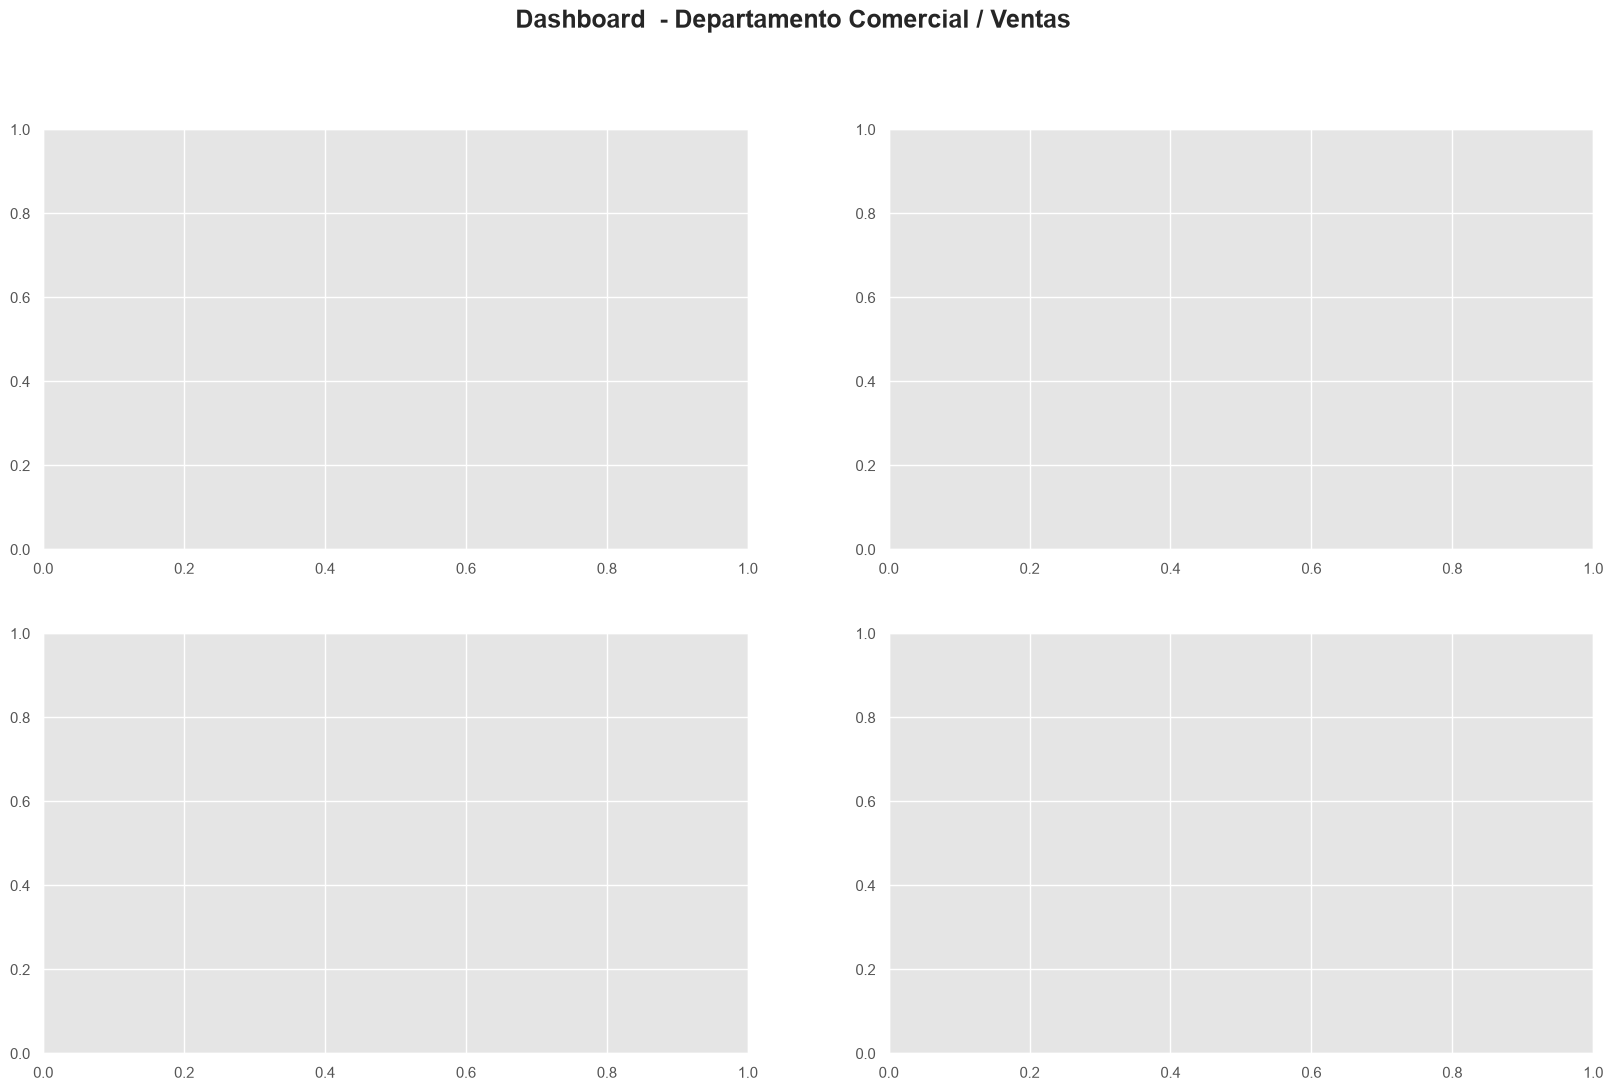

In [304]:
fig, axes = plt.subplots(
    2,     # 2 columnas
    2,     # 2 filas
    figsize=(20,12)
)

fig.suptitle(
    "Dashboard  - Departamento Comercial / Ventas",
    fontsize=18,
    fontweight="bold"
)

**>> GRÁFICO 1: EVOLUCIÓN DE LAS VENTAS / INGRESOS MENSUALES**

💠Utilizaremos el gráfico de líneas ya creado en el ejercicio 1 para mostraral equipo comercial y que puedan ver de manera clara cómo las ventas han evolucionado a lo largo del tiempo. Con esto, podemos ayudarles a  ver si hay algún patrón, pico de ventas, etc y puedan trabajar en base a esta información.

In [305]:
df_transactions

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,is_international,decline_reason,distance_km,date,month,hour,status,week_day,year,time_slot
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,0,,59.95,2024-08-28,August,7,Accepted,Wednesday,2024,Morning
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,1,,1157.10,2020-07-14,July,15,Accepted,Tuesday,2020,Afternoon
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,...,0,,540.32,2017-09-04,September,19,Accepted,Monday,2017,Night
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,...,0,,28.52,2017-01-05,January,18,Accepted,Thursday,2017,Night
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,...,0,,539.82,2023-09-23,September,4,Accepted,Saturday,2023,Early morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,CcS-5010,b-2234,2022-12-17 20:57:55,278.42,0,"20, 42, 54, 46",429,52.5223,13.40490,...,0,,0.25,2022-12-17,December,20,Accepted,Saturday,2022,Night
99995,FFFB270D-F53A-4D5D-9666-E5307C53CC84,CcS-7655,b-2522,2024-05-13 03:42:03,403.66,0,"30, 87, 5, 66",3074,39.0271,-8.10523,...,0,,42.71,2024-05-13,May,3,Accepted,Monday,2024,Early morning
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,2019-10-30 02:31:37,295.43,0,"16, 49",1008,59.3327,18.07530,...,0,,0.53,2019-10-30,October,2,Accepted,Wednesday,2019,Early morning
99997,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,2023-06-17 19:10:30,183.02,0,18,680,52.0635,4.30862,...,0,,67.56,2023-06-17,June,19,Accepted,Saturday,2023,Night


In [306]:
df_transactions = df_transactions[df_transactions["declined"] == 0]

In [307]:
df_transactions["month"] = df_transactions["timestamp"].dt.to_period("M").dt.to_timestamp()
monthly_sales = df_transactions.groupby("month")["amount"].sum()

In [308]:
monthly_sales

month
2015-01-01    221978.21
2015-02-01    245780.13
2015-03-01    253000.65
2015-04-01    245597.21
2015-05-01    248585.36
                ...    
2024-08-01    236671.63
2024-09-01    234226.89
2024-10-01    254314.46
2024-11-01    233891.19
2024-12-01    249279.90
Name: amount, Length: 120, dtype: float64

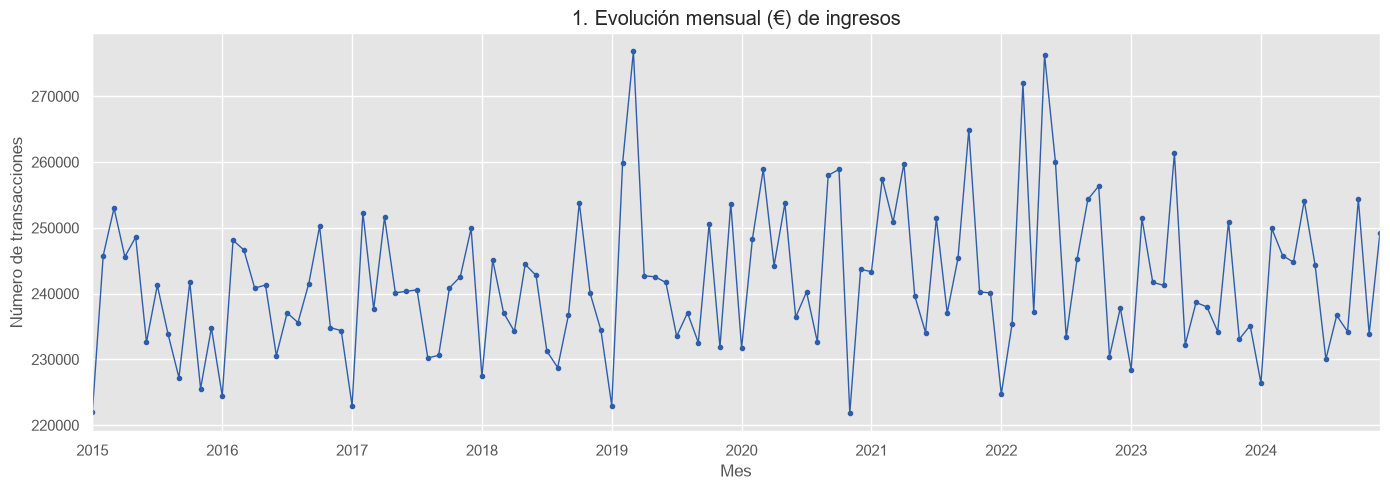

In [309]:
ejes = monthly_sales.plot(
    figsize=(14, 5),
    marker="o",
    markersize=3,
    linewidth=1,
    color="#2E5EAA",
    title="1. Evolución mensual (€) de ingresos"
)
ejes.set_xlabel("Mes")
ejes.set_ylabel("Número de transacciones")
plt.tight_layout()
plt.show()

**>> GRÁFICO 2: TOP 10 PAÍSES / INGRESOS**

💠Otro gráfico que puede aportar información relevante al dashboard es un top 10 de países que más facturan para analizar la diversificación geográfica de las ventas.

💠 Aprovecharemos la información obtenida en el ejercicio 2 para mostrar con un gráfico de barras los 10 países.

In [310]:
top10_countries = revenue_country.head(10)

In [311]:
top10_countries = top10_countries[["country", "amount"]]

In [312]:
top10_countries

,country,amount
12,Sweden,4928117.68
8,Netherlands,4506571.38
13,United Kingdom,4099117.08
7,Italy,4087557.38
5,Germany,4020364.07
4,France,1416084.26
14,United States,1101737.27
1,Belgium,952208.75
10,Norway,809288.82
6,Ireland,715220.46


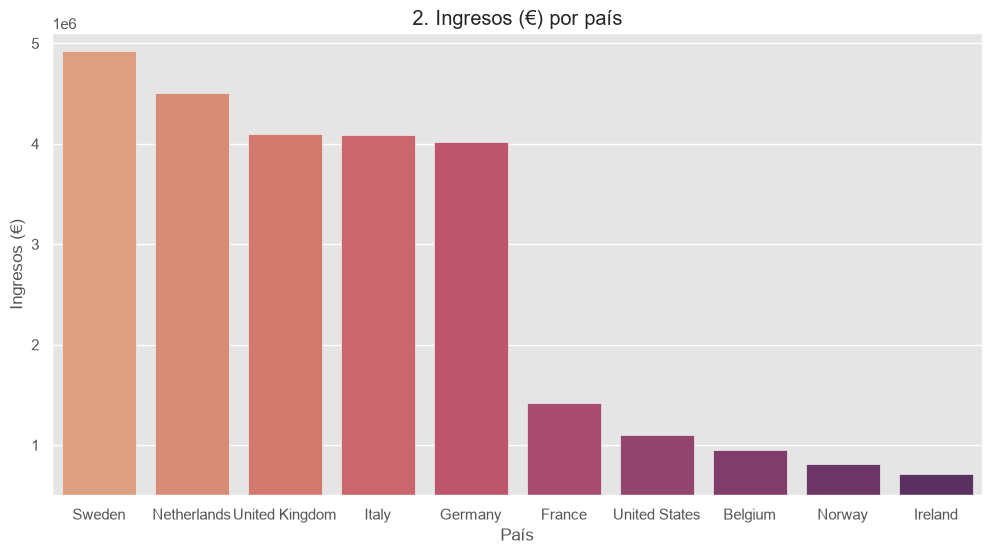

In [313]:
sns.barplot(x=top10_countries.country,
            y=top10_countries.amount,
            hue=top10_countries.country,
            palette="flare",
            legend=False)



plt.ylim(500000, 5100000)
plt.title("2. Ingresos (€) por país")
plt.xlabel("País")
plt.ylabel("Ingresos (€)")

plt.show()


**>> GRÁFICO 3: TOP 10 PRODUCTOS / INGRESOS**

💠Para incrementar ventas es importante saber qué es lo que vendemos. De esta manera, podemos poner más hincapié en aquellos productos con más éxito e incrementar el stock, por ejemplo.

💠 Utilizaremos para respresentarlo un gráfico de barras horizontal, me parece más visual ver en orden descendente los ingresos de cada uno.

In [314]:
top10_products = top15_products.sort_values("amount", ascending=False).head(10)
top10_products

,product_ids,amount
38,39,1154841.34
66,67,1154360.96
63,64,1152983.78
11,12,1137696.37
14,15,1131994.63
92,93,1130606.39
15,16,1130601.86
61,62,1129275.97
85,86,1116933.98
22,23,1109587.67


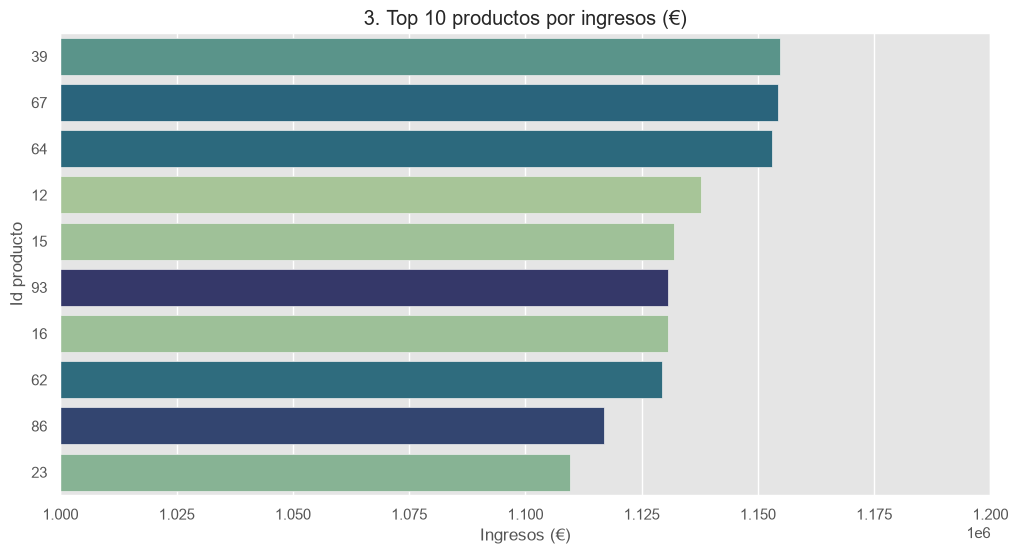

In [315]:
sns.barplot(data=top10_products,
            x="amount",
            y="product_ids",
            hue="product_ids",
            palette="crest",
            orient="h",
            legend=False,
            order=top10_products["product_ids"])

plt.xlim(1000000, 1200000)

plt.title("3. Top 10 productos por ingresos (€)")

plt.xlabel("Ingresos (€)")
plt.ylabel("Id producto")

plt.show()


**>> GRÁFICO 4: VENTAS NACIONALES / INTERNACIONALES**

💠 Otra información que considero relevante es el número de ventas / ingresos que se realizan desde local. Importante para desarrollar mercados.

💠 Al tratarse de 2 variables, un gráfico de tarta es muy visual, nos dará una idea clara y concisa del porcentaje.

In [316]:
sales_type = df_transactions.groupby("is_international")["amount"].sum()
sales_type.index = sales_type.index.map({0: "Nacional", 1: "Internacional"})
sales_type


is_international
Nacional         24815095.23
Internacional     4210114.62
Name: amount, dtype: float64

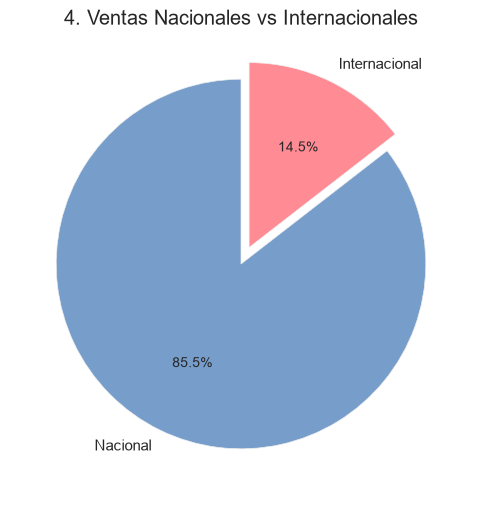

In [317]:
sales_type.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    ylabel="",
    colors=["#779ecb", "#FF8B94"],
    explode=[0, 0.1]
)

plt.title("4. Ventas Nacionales vs Internacionales")

plt.show()

In [318]:
ax=axes[0,0]

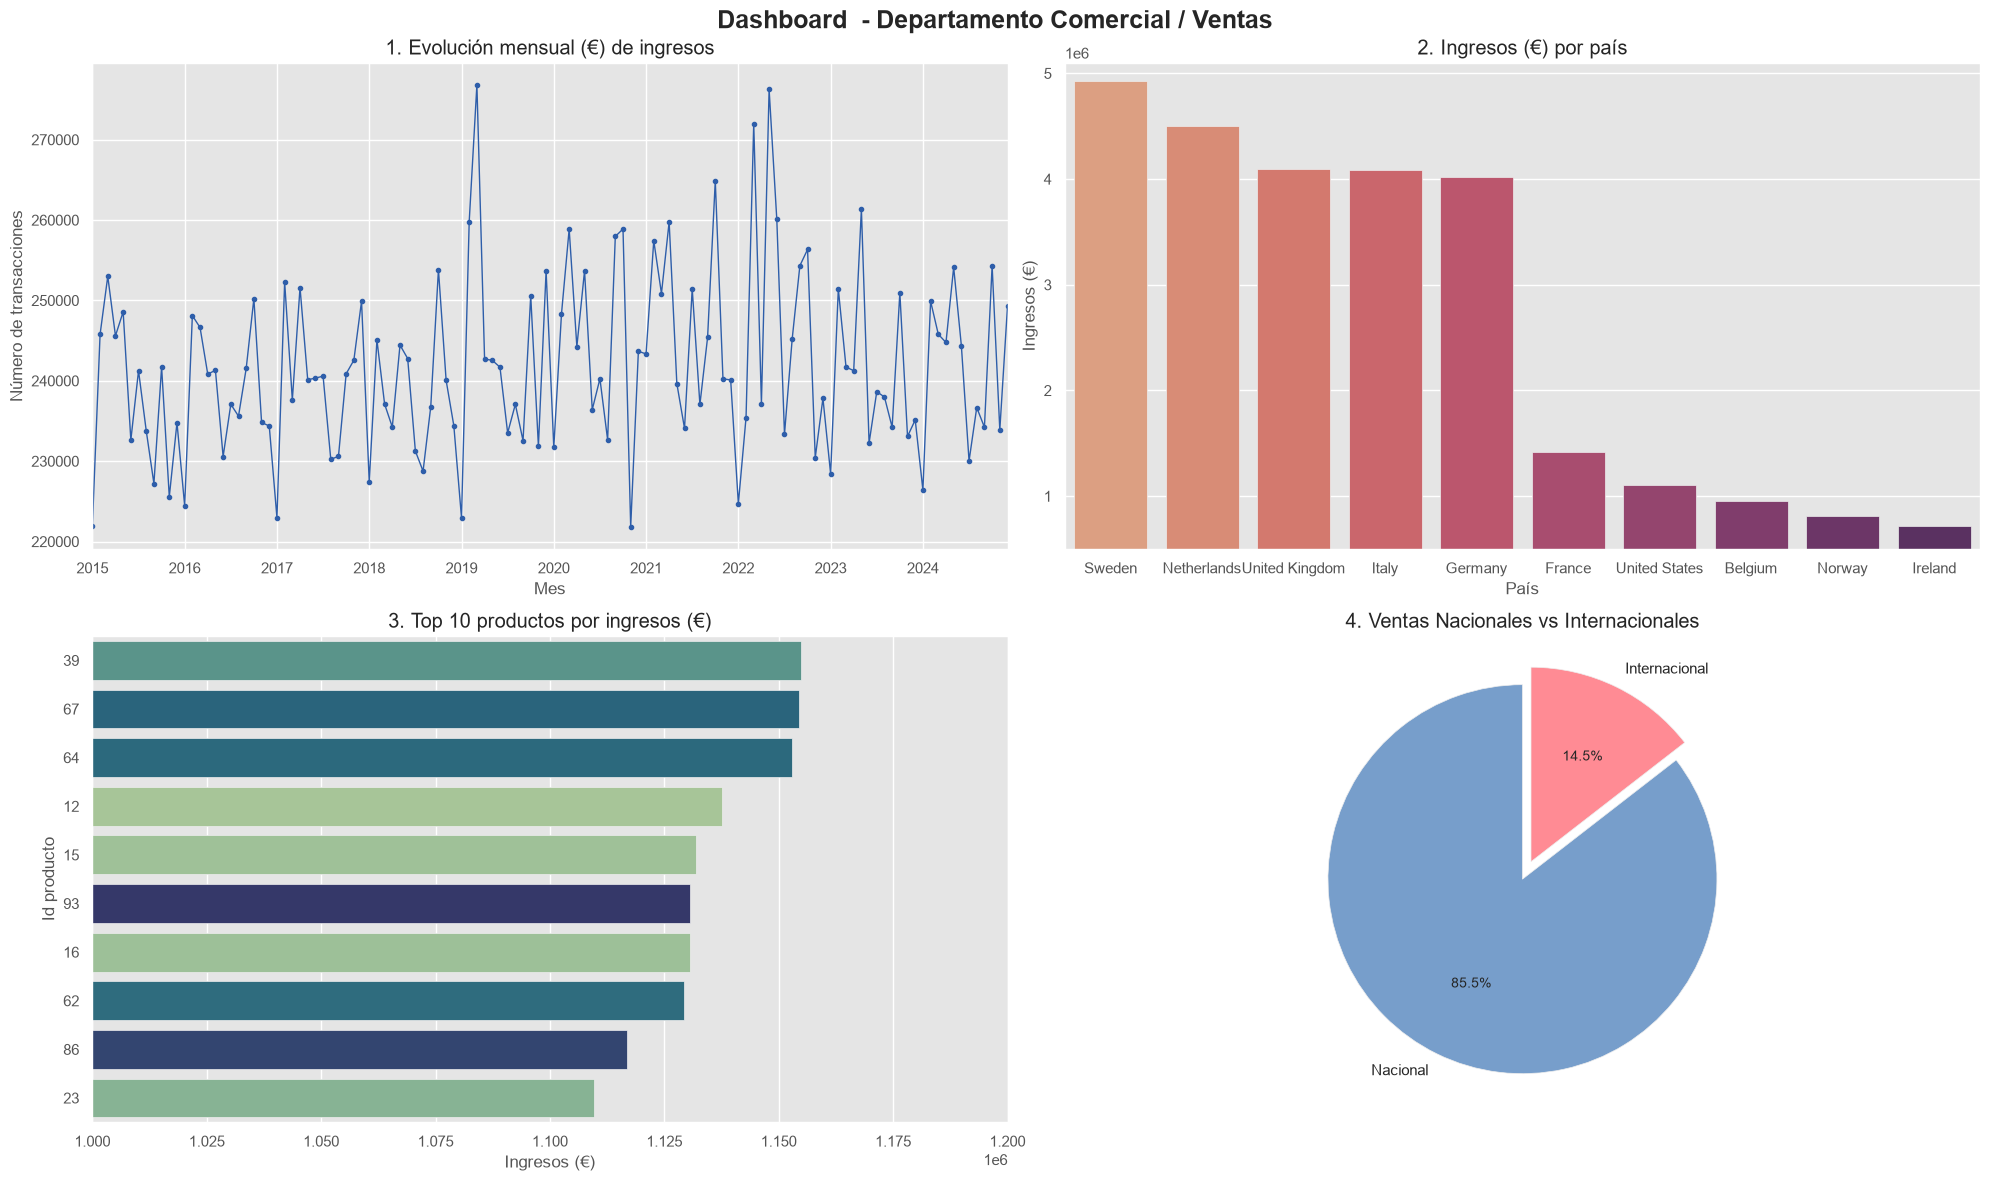

In [319]:
# FIGURA PPAL

fig, axes = plt.subplots(
    2,     # 2 columnas
    2,     # 2 filas
    figsize=(20,12)
)

fig.suptitle(
    "Dashboard  - Departamento Comercial / Ventas",
    fontsize=18,
    fontweight="bold"
)

# GRAFICO 1
ejes = monthly_sales.plot(
    ax=axes[0,0],
    marker="o",
    markersize=3,
    linewidth=1,
    color="#2E5EAA",
    title="1. Evolución mensual (€) de ingresos"
)
axes[0, 0].set_xlabel("Mes")
axes[0, 0].set_ylabel("Número de transacciones")

# GRAFICO 2
sns.barplot(
    x=top10_countries.country,
    y=top10_countries.amount,
    hue=top10_countries.country,
    palette="flare",
    legend=False,
    ax=axes[0, 1] # <-- Se posiciona arriba a la derecha
)
axes[0, 1].set_ylim(500000, 5100000)
axes[0, 1].set_title("2. Ingresos (€) por país")
axes[0, 1].set_xlabel("País")
axes[0, 1].set_ylabel("Ingresos (€)")

# GRAFICO 3

sns.barplot(data=top10_products,
            x="amount",
            y="product_ids",
            hue="product_ids",
            ax=axes[1,0],
            palette="crest",
            orient="h",
            legend=False,
            order=top10_products["product_ids"])

axes[1, 0].set_xlim(1000000, 1200000)
axes[1, 0].set_title("3. Top 10 productos por ingresos (€)")
axes[1, 0].set_xlabel("Ingresos (€)")
axes[1, 0].set_ylabel("Id producto")

# GRAFICO 4
sales_type.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    ylabel="",
    ax=axes[1,1],
    colors=["#779ecb", "#FF8B94"],
    explode=[0, 0.1]
)

axes[1, 1].set_title("4. Ventas Nacionales vs Internacionales")


plt.tight_layout()
plt.show()


## **Ejercicio 2: Informe ejecutivo**

🎯 **Objetivo:** Basándote en el panel de control, presenta un informe ejecutivo en dos versiones:

* Sin IA
* Con ayuda de la IA

**» Sin IA:**

+ Redactado con tus propias palabras.

**» Con ayuda de la IA:**

* Utilizando herramientas de IA para:
  * Mejorar la redacción.
  * Adaptar el lenguaje al departamento elegido.
  * Incorporar vocabulario técnico empresarial.

**El informe debe incluir:**

1. Resumen ejecutivo (máx. 5 líneas): qué se ha analizado y con qué finalidad.

2. Conclusiones clave (3-5): ideas sólidas basadas en datos reales.

3. Riesgos identificados: por ejemplo, dependencia excesiva de productos o empresas, incapacidad para captar nuevos usuarios, franjas horarias críticas, posibles indicios de fraude o anomalías...

4. Oportunidades: mejoras operativas, segmentos sin explotar, productos o franjas horarias con potencial, optimización de recursos...

5. Recomendaciones: medidas concretas, no técnicas y orientadas al negocio.


---

## 📄 **Informe ejecutivo - Silvia Vílches**

### 1. Resumen ejecutivo
En esto informe hemos analizado los últimos 9 años de transacciones de la empresa (2015-2024) para ver cómo evolucionan los ingresos en las ventas, qué productos y qué países las generan, y en qué porcentaje las ventas dependen delmercado nacional o internacional. El objetivo de este informe es detectar valores que no sean propios de una empresa internacional y oportunidades que puedan ayudar el equipo de Ventas.

### 2. Conclusiones clave
- Los ingresos mensuales se mantienen bastante estables a lo largo de los años, no hay cremiento orgánico.
- Los ingresos vienen sobre todo de 10 países, teniendo en cuenta que el groso de las ventas se centran únicamente en 5.
- El top 10 de productos genera ingresos muy parecidos entre sí, no hay niguno que destaque de manera excepcional.
- El 85,5% de las ventas son nacionales y solo el 14,5% son internacionales.

### 3. Riesgos identificados
- La empresa no está creciendo: el nivel de ingresos no evoluciona significativamente, se mantiene estable durante 9 años.
- La empresa depende mucho de únicamente 5 países: ésto conlleva riesgos.
- Casi todo el negocio depende del marcado nacional.

### 4. Oportunidades
- Se podría intentar vender más fuera del país, ya que ahora mismo es solo el 14,5% del negocio.
- Identificar nuevos mercados locales como Portugal o Polonia que no producen ventas locales.
- Los productos "emergentes" (los que traen clientes nuevos aunque todavía facturan poco) se podrían potenciar más.


### 5. Recomendaciones
- Nuevas NL desde el equipo de marketing para los productos "emergentes" o "nuevos", para atrer más usuarios neuvos.
- Potenciar acciones de marketing más agresivas en fechas clave (Navidad, verano, SS, BF), campañas de fidelidad, etc para ayudar al crecimiento de las ventas.
- Estudiar por qué las ventas internacionales son tan bajas y si merece la pena potenciarlas.
- Revisar los países con muy pocas transacciones para descartar errores antes de tomar decisiones sobre ellos.

---

---

## ✨ **Informe ejecutivo - IA Gemini**

### 1. Resumen ejecutivo

Este informe analiza los datos históricos de ventas del Departamento Comercial y de Ventas desde 2015 hasta finales de 2024. El objetivo es evaluar la evolución de los ingresos, el rendimiento geográfico, el éxito de los productos y la proporción entre el mercado nacional e internacional para identificar riesgos y oportunidades de crecimiento.

### 2. Conclusiones clave

* **Dominio del Mercado Nacional:** Las ventas nacionales impulsan fuertemente el negocio, representando el 85,5% de los ingresos totales.
* **Líderes Geográficos:** Suecia, Países Bajos y el Reino Unido son los tres países internacionales que más ingresos aportan.
* **Productos Top:** Los productos '39', '67' y '64' son los que generan mayores ingresos, superando cada uno los 1.150 millones de euros (€) o 1,15×10⁸.
* **Ingresos Cíclicos:** Los ingresos muestran un patrón altamente volátil y cíclico, con picos y caídas pronunciadas y recurrentes a lo largo de cada año.
* **Tendencia a Largo Plazo Estancada:** A pesar de los picos individuales, la base mensual de transacciones se ha mantenido plana entre el rango de 220.000 y 270.000 durante una década.

### 3. Riesgos identificados

* **Dependencia Excesiva del Mercado Interno:** Depender del mercado nacional para el 85,5% de los ingresos expone al negocio a una gran vulnerabilidad ante posibles crisis económicas locales.
* **Volatilidad de los Ingresos:** Las severas fluctuaciones mensuales sugieren un flujo de caja inestable, lo que puede complicar la planificación de inventarios y recursos.
* **Concentración de Productos:** Un grupo reducido de productos (los 3 primeros) concentra una parte desproporcionada de los ingresos más altos.
* **Regiones con Bajo Rendimiento:** Mercados como Irlanda, Noruega y Bélgica aportan cantidades insignificantes en comparación con sus pares nórdicos.


### 4. Oportunidades

* **Expansión Internacional Inexplorada:** Las ventas internacionales representan solo el 14,5% del negocio, lo que deja un margen enorme para expandirse en los mercados europeos existentes.
* **Replicar el Éxito Nórdico:** Analizar por qué Suecia y los Países Bajos superan a otras naciones podría revelar estrategias para impulsar las regiones rezagadas como Noruega.
* **Diversificación de Productos:** Crear paquetes que combinen productos de menor rendimiento (como el '86' o el '23') con los de nivel superior ('39', '67') puede elevar las ventas globales de la cartera.
* **Suavizar las Caídas Estacionales:** Implementar promociones específicas durante las épocas del año donde históricamente caen las transacciones ayudaría a estabilizar los ingresos.

### 5. Recomendaciones
* **Lanzar Campañas Internacionales Focalizadas:** Asignar presupuesto de marketing a Reino Unido, Italia y Alemania para convertirlos en centros de alto volumen como Suecia.
* **Implementar Precios Dinámicos Estacionales:** Crear programas de fidelización o modelos de suscripción en temporadas bajas para equilibrar las caídas bruscas de transacciones mensuales.
* **Diversificar la Oferta Comercial:** Introducir incentivos de venta cruzada en el equipo comercial para impulsar los productos intermedios y reducir la dependencia de los tres artículos principales.
* **Evaluar la Saturación del Mercado Nacional:** Realizar un estudio del mercado local para verificar si el segmento nacional ha tocado techo, desplazando el enfoque hacia la captación internacional si fuera necesario.